In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import math
from lifelines.utils import survival_table_from_events
from lifelines import KaplanMeierFitter, WeibullAFTFitter, CoxPHFitter
from lifelines.utils import k_fold_cross_validation, concordance_index
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

In [2]:
df_gbsg = pd.read_csv("./data/gbsg.csv")
df_hm = pd.read_csv("./data/haberman.csv")
df_pbc = pd.read_csv("./data/pbc.csv")
df_sd = pd.read_csv("./data/simulated_data.csv")

In [3]:
def compute_ibs(cph, df, duration_col, event_col):
    # sksurv structured array
    y = Surv.from_arrays(
        event=df[event_col].astype(bool).values,
        time=df[duration_col].values
    )

    t_min = df[duration_col].min()
    t_max = df[duration_col].max()

    # IMPORTANT: times must be strictly inside (t_min, t_max)
    eps = (t_max - t_min) * 0.001
    times = np.linspace(t_min + eps, t_max - eps, 100)

    # lifelines survival predictions (times x samples)
    surv_df = cph.predict_survival_function(df, times=times)

    # Convert to (samples x times)
    surv_preds = surv_df.T.values

    ibs = integrated_brier_score(
        y,          # training data
        y,          # test data (same here)
        surv_preds,
        times
    )

    return ibs

### GBSG

In [4]:
df_gbsg.shape

(686, 12)

In [5]:
df_gbsg.head(10)

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
0,1,132,49,0,18,2,2,0,0,0,1838,0
1,2,1575,55,1,20,3,16,0,0,0,403,1
2,3,1140,56,1,40,3,3,0,0,0,1603,0
3,4,769,45,0,25,3,1,0,4,0,177,0
4,5,130,65,1,30,2,5,0,36,1,1855,0
5,6,1642,48,0,52,2,11,0,0,0,842,1
6,7,475,48,0,21,3,8,0,0,0,293,1
7,8,973,37,0,20,2,9,0,0,1,42,0
8,9,569,67,1,20,2,1,0,0,1,564,1
9,10,1180,45,0,30,2,1,0,0,0,1093,1


In [6]:
df_gbsg = df_gbsg.drop(['pid', 'Unnamed: 0'], axis=1)

In [7]:
df_gbsg.isna().sum()

age        0
meno       0
size       0
grade      0
nodes      0
pgr        0
er         0
hormon     0
rfstime    0
status     0
dtype: int64

In [8]:
df_gbsg.describe()

,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,53.052478,0.577259,29.329446,2.116618,5.010204,109.995627,96.252187,0.358601,1124.489796,0.435860
std,10.120739,0.494355,14.296217,0.582808,5.475483,202.331552,153.083963,0.479940,642.791948,0.496231
min,21.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,46.000000,0.000000,20.000000,2.000000,1.000000,7.000000,8.000000,0.000000,567.750000,0.000000
50%,53.000000,1.000000,25.000000,2.000000,3.000000,32.500000,36.000000,0.000000,1084.000000,0.000000
75%,61.000000,1.000000,35.000000,2.000000,7.000000,131.750000,114.000000,1.000000,1684.750000,1.000000
max,80.000000,1.000000,120.000000,3.000000,51.000000,2380.000000,1144.000000,1.000000,2659.000000,1.000000


In [9]:
print(df_gbsg["status"].value_counts())

print("\nIn Percentage:")
print(df_gbsg['status'].value_counts(normalize = True) )

status
0    387
1    299
Name: count, dtype: int64

In Percentage:
status
0    0.56414
1    0.43586
Name: proportion, dtype: float64


In [10]:
event_rate = df_gbsg["status"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")


Event rate: 0.44
Censoring rate: 0.56


In [11]:
# Create log features for skewed data
df_gbsg['log_nodes'] = np.log1p(df_gbsg['nodes'])
df_gbsg['log_pgr'] = np.log1p(df_gbsg['pgr'])
df_gbsg['log_er'] = np.log1p(df_gbsg['er'])


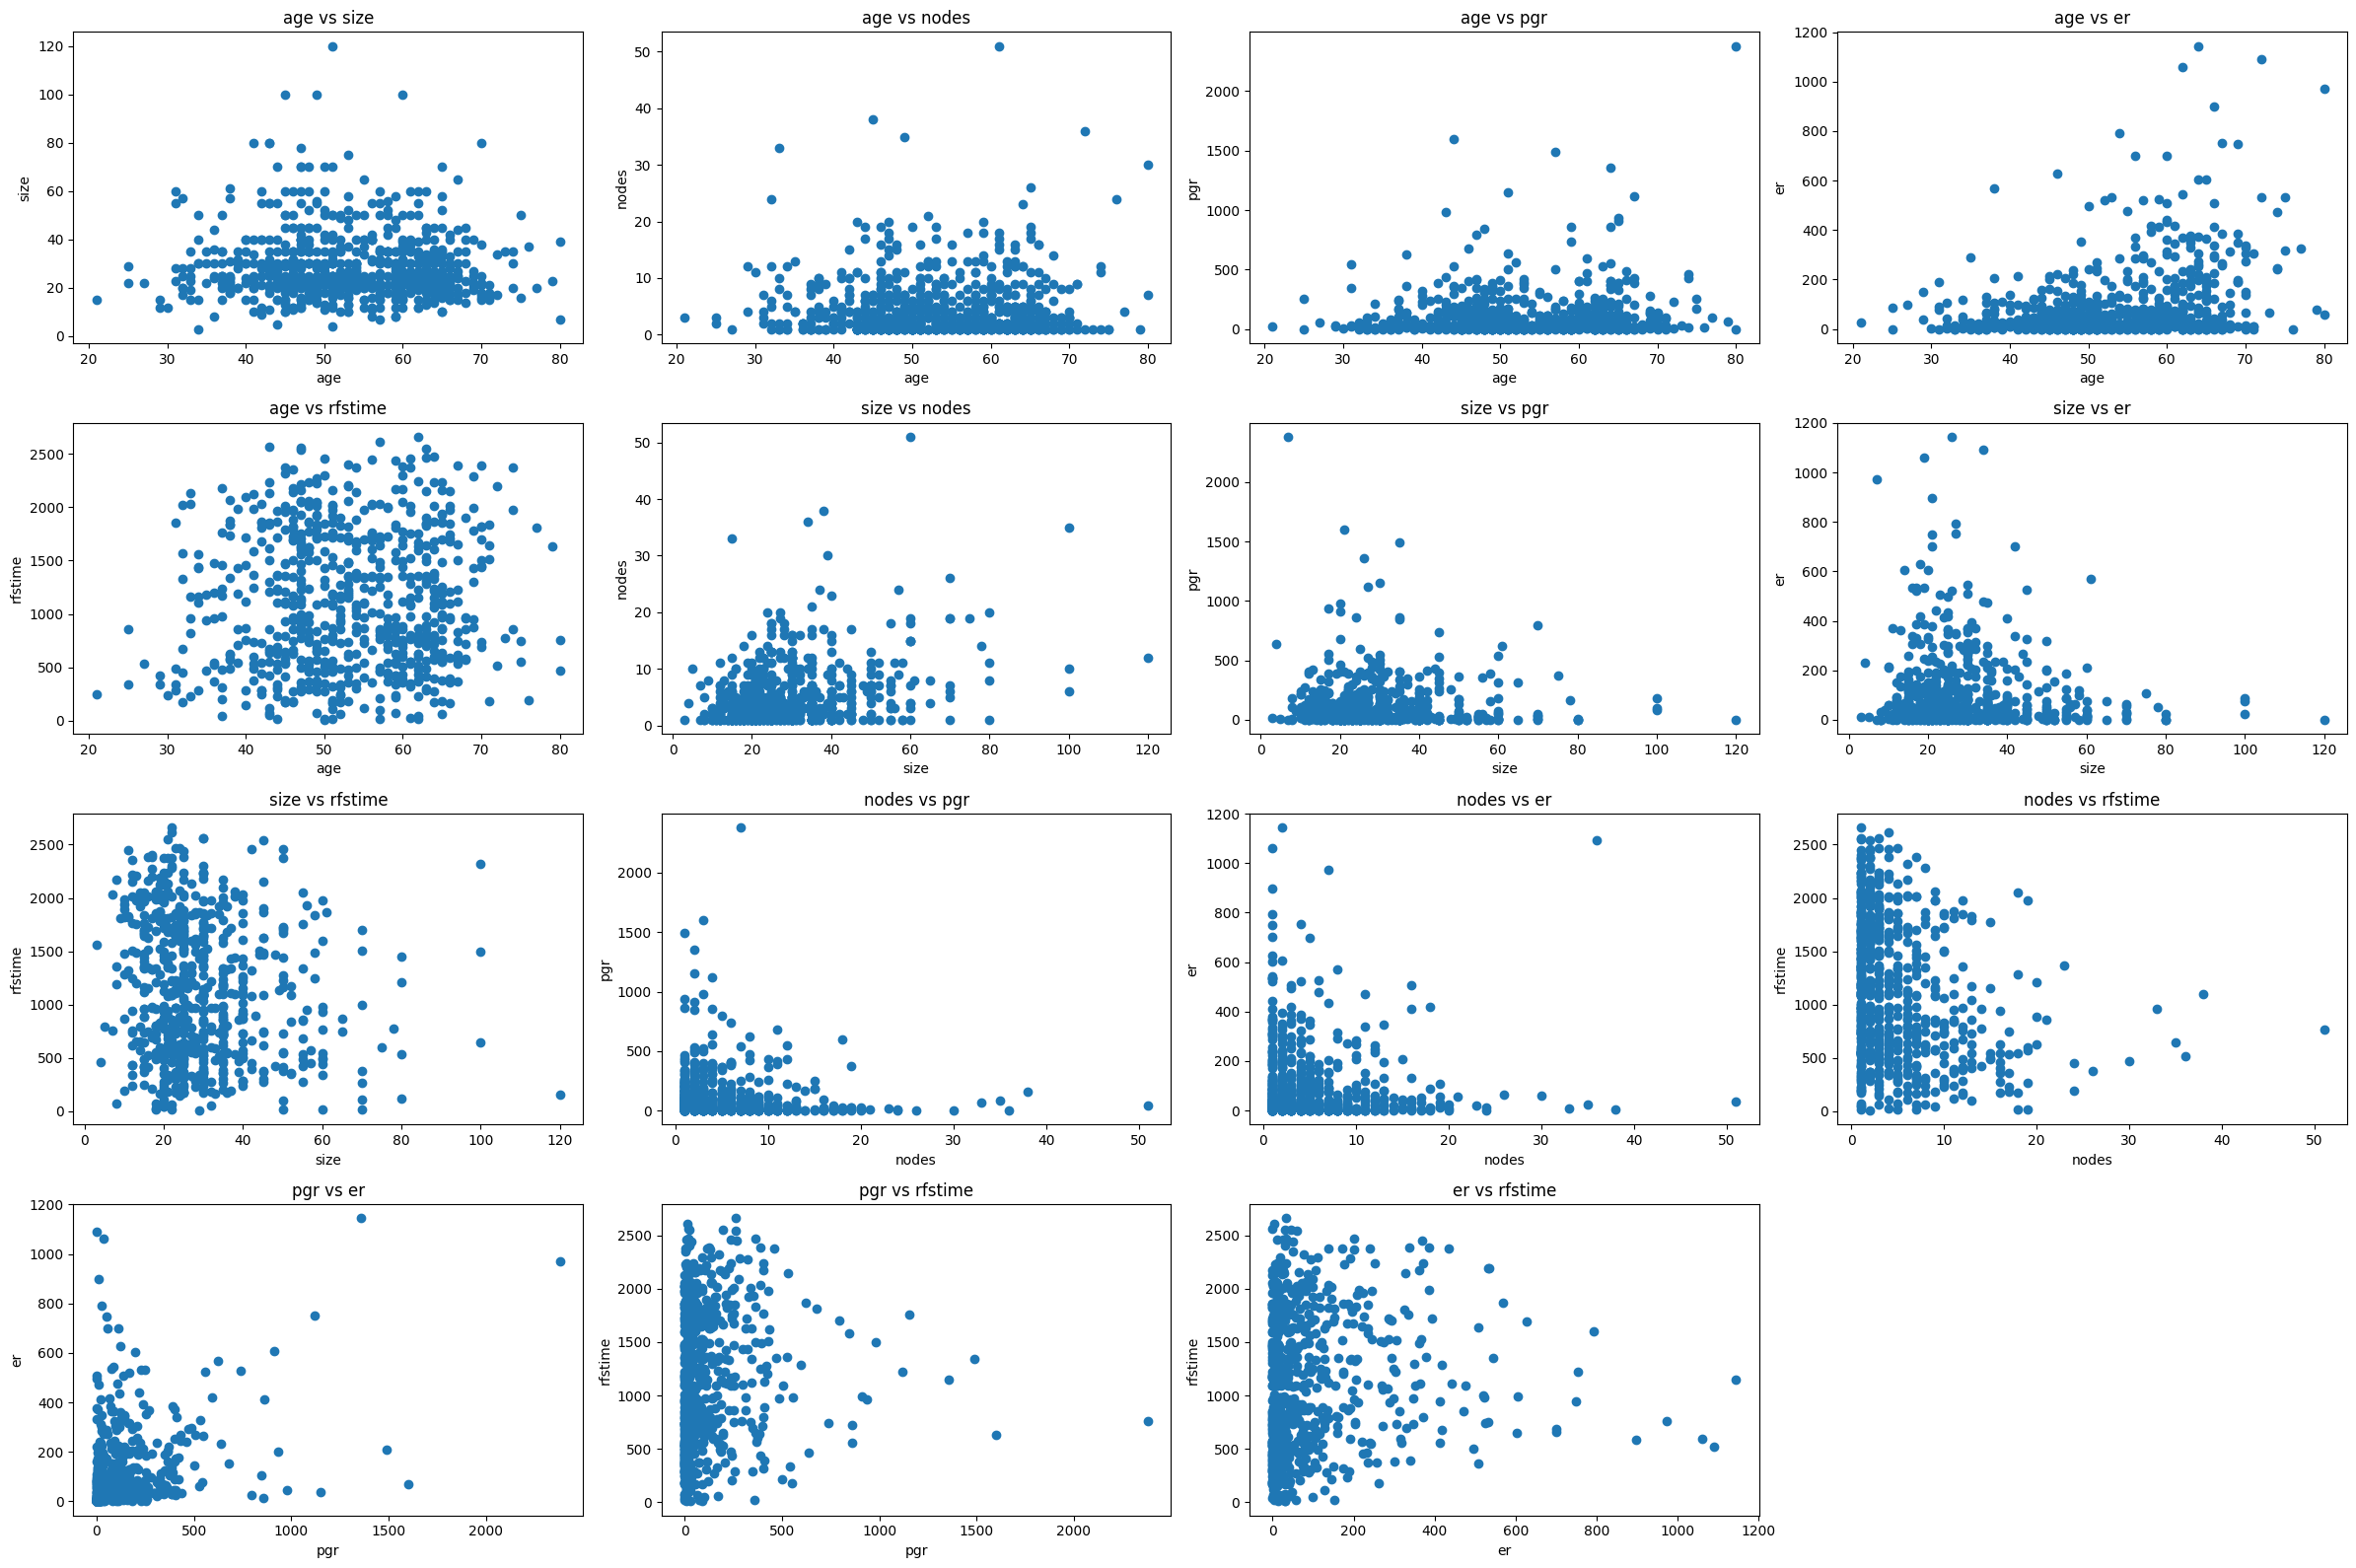

In [12]:
cols = ['age', 'size', 'nodes', 'pgr', 'er', 'rfstime']


pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

# Grid size (4 columns)
cols_grid = 4
rows_grid = math.ceil(n / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(6*cols_grid, 4*rows_grid))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_gbsg[x], df_gbsg[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

# Turn off empty plots if any
for i in range(len(pairs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

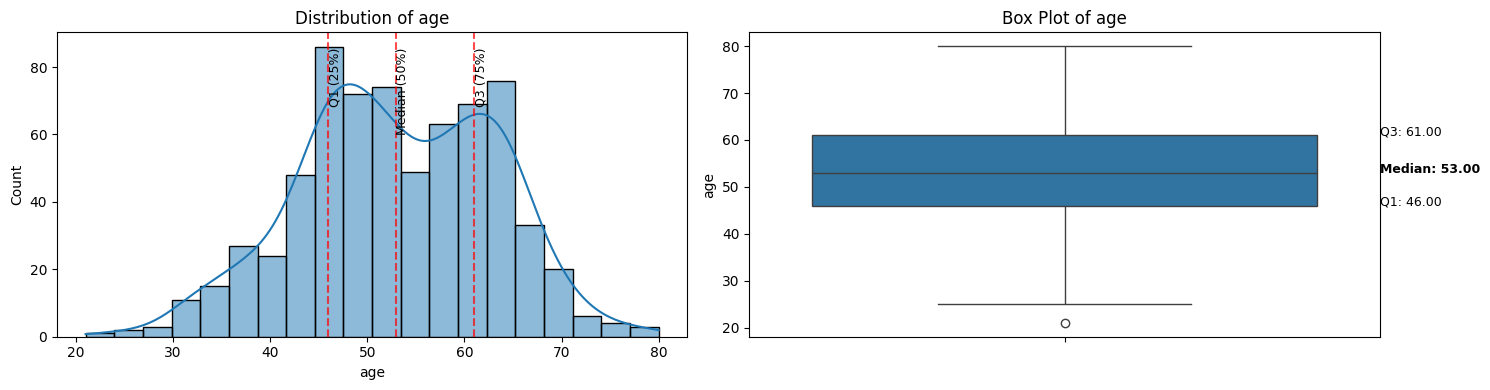

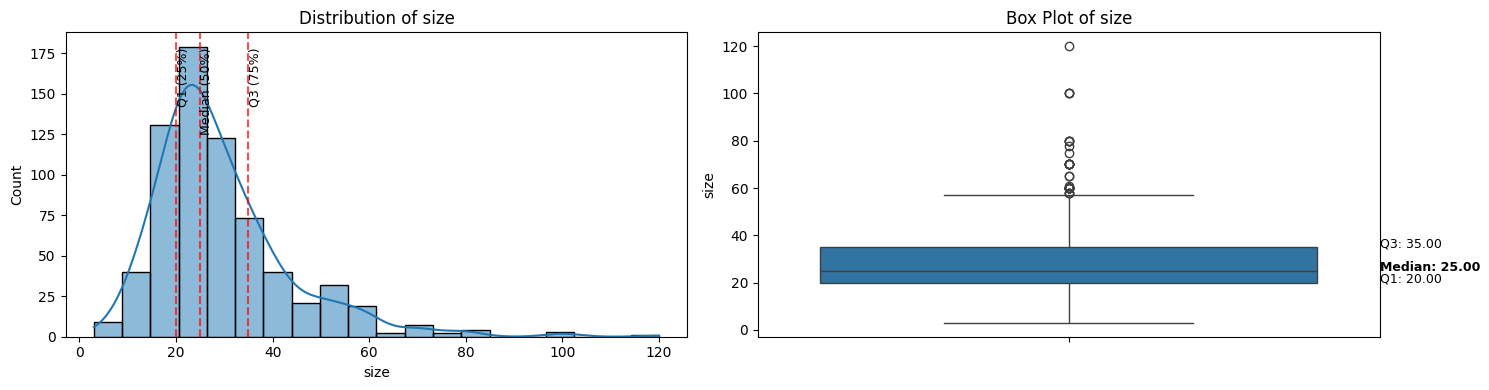

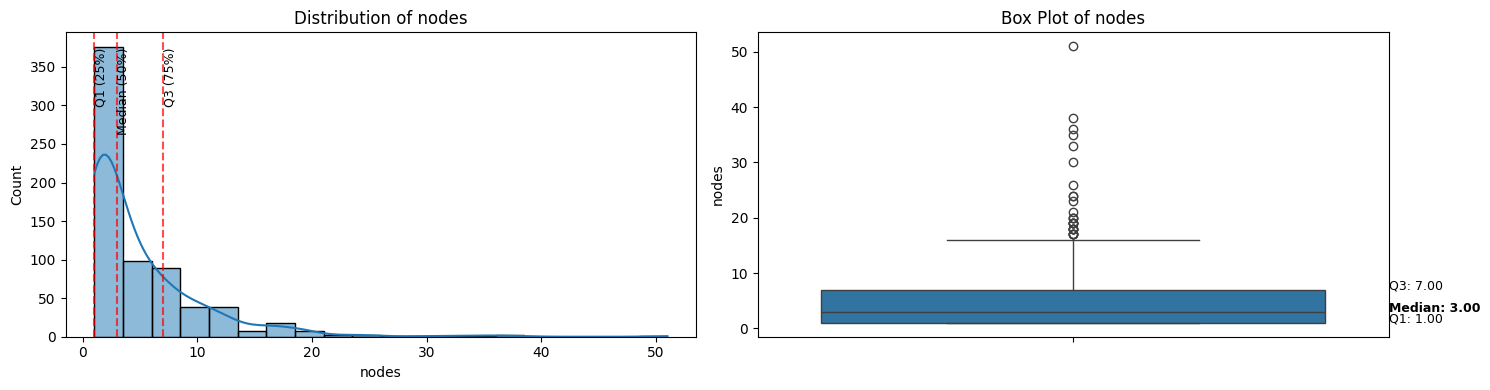

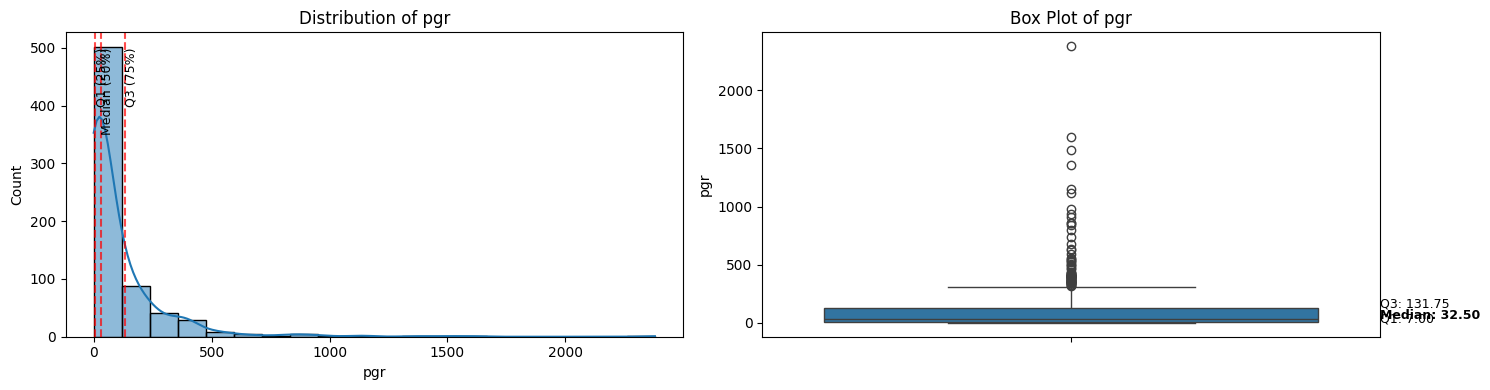

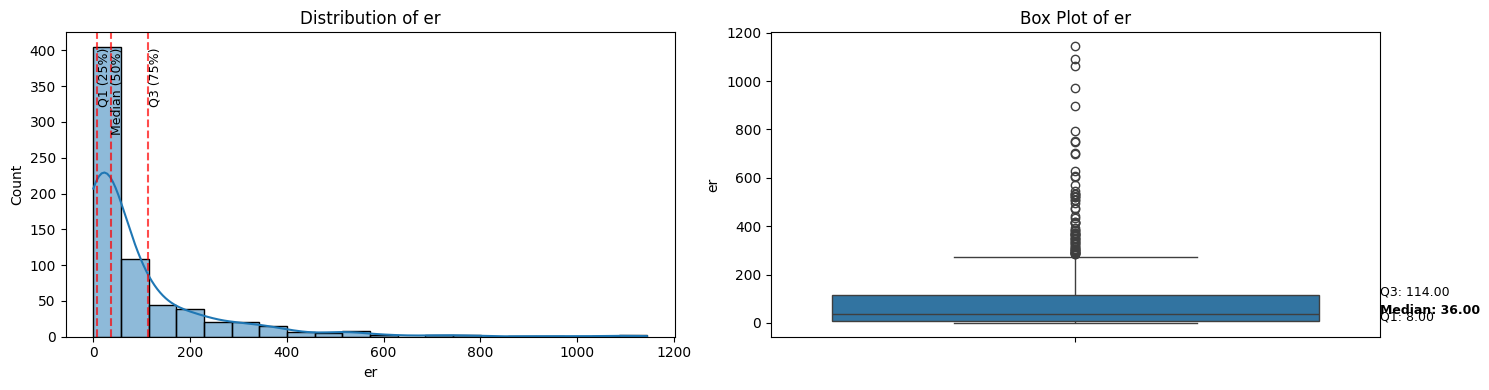

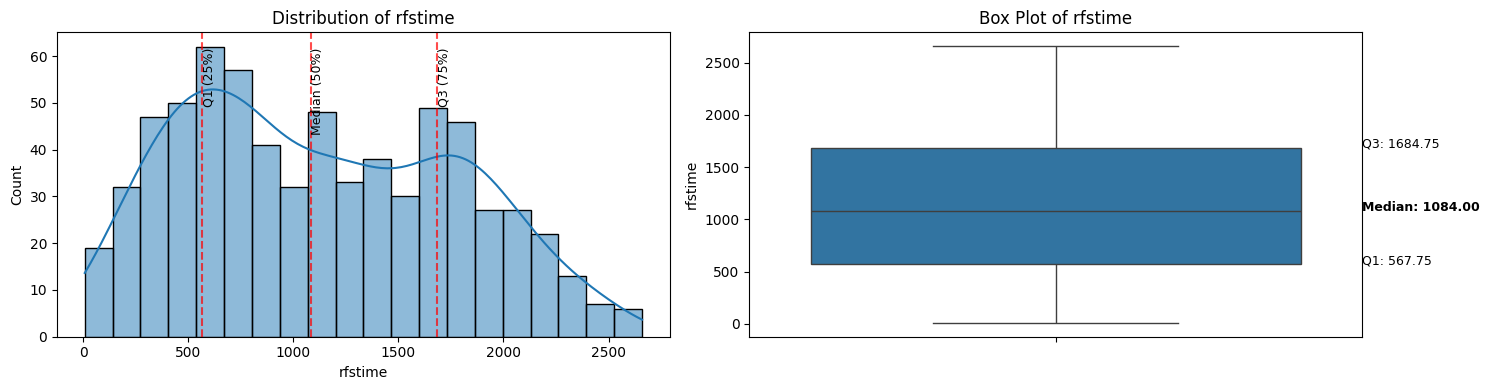

In [13]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Histogram with quantiles
    sns.histplot(data=df_gbsg, x=col, kde=True, bins=20, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    # Add quantile lines (25th, 50th, 75th percentiles)
    quantiles = df_gbsg[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
      
    # Plot 2: Box plot with quantile annotations
    sns.boxplot(data=df_gbsg, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    # Add quantile values as text on boxplot
    q1, median, q3 = df_gbsg[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

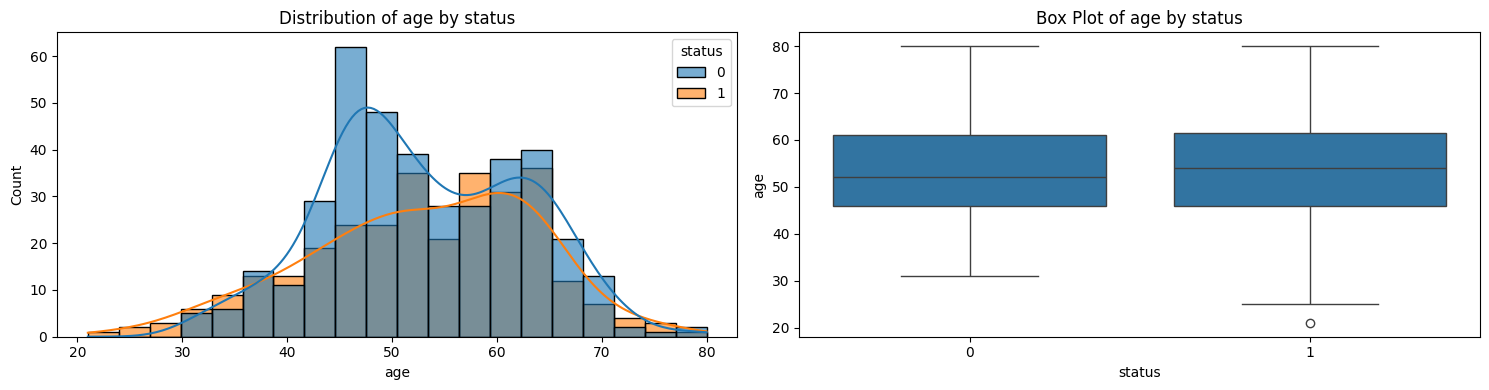

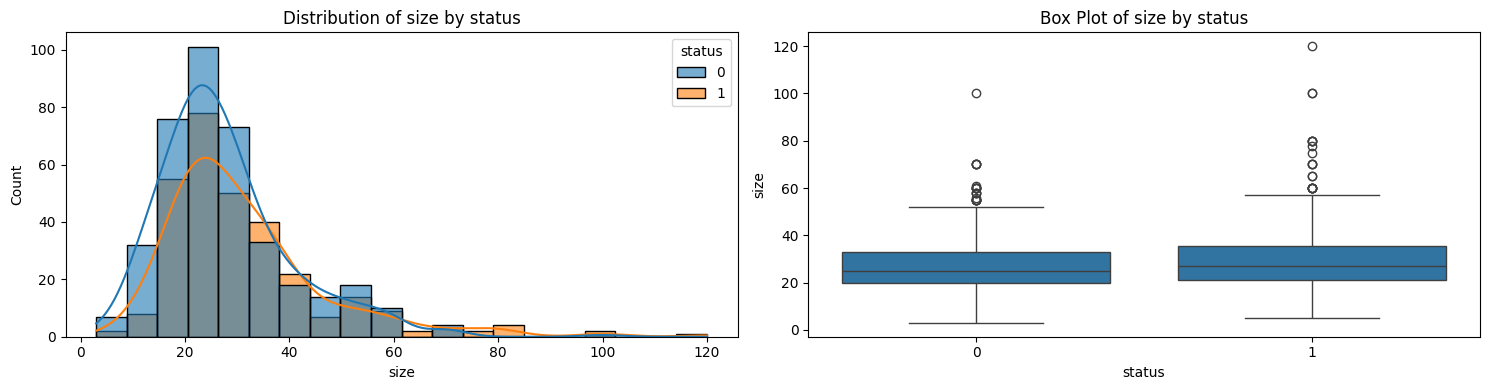

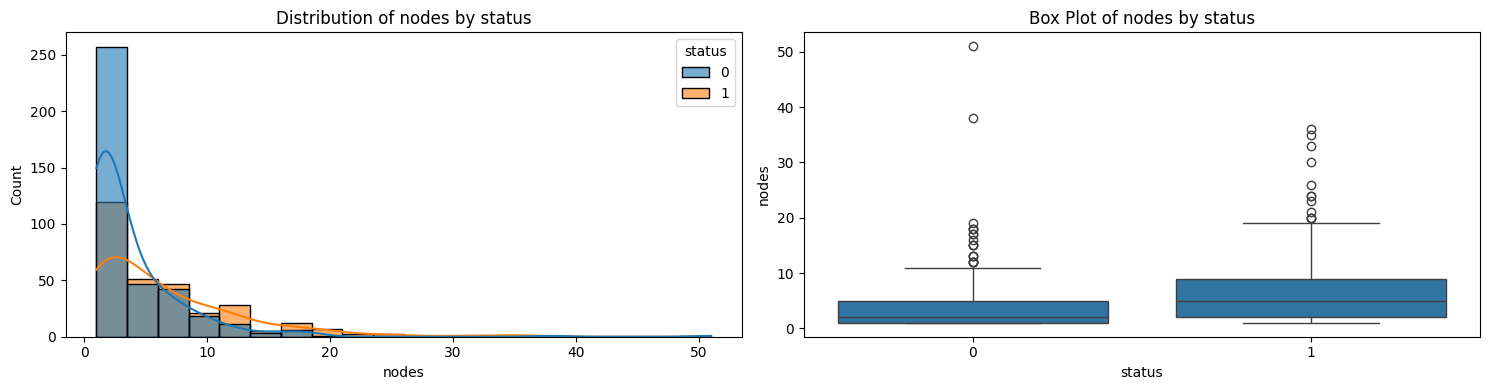

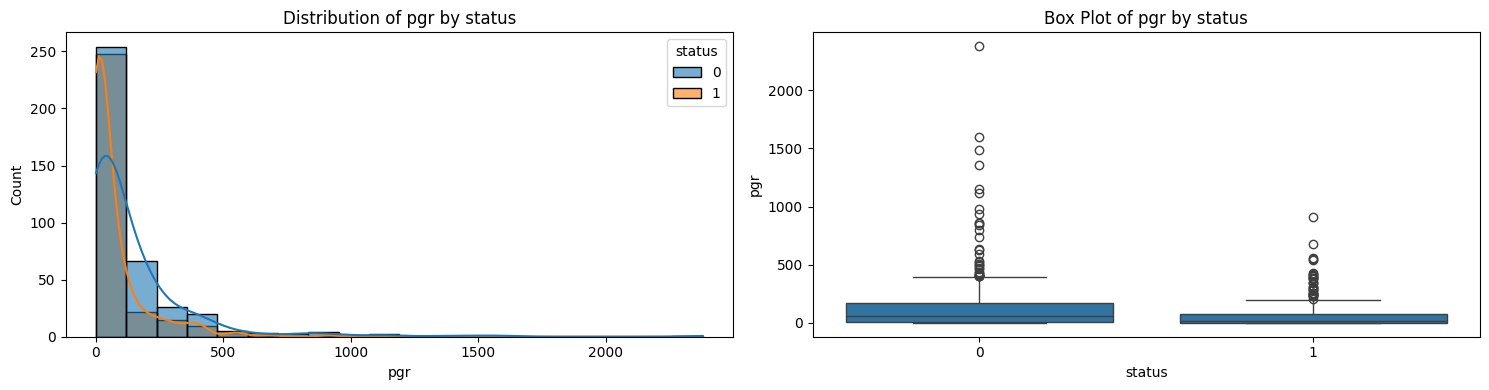

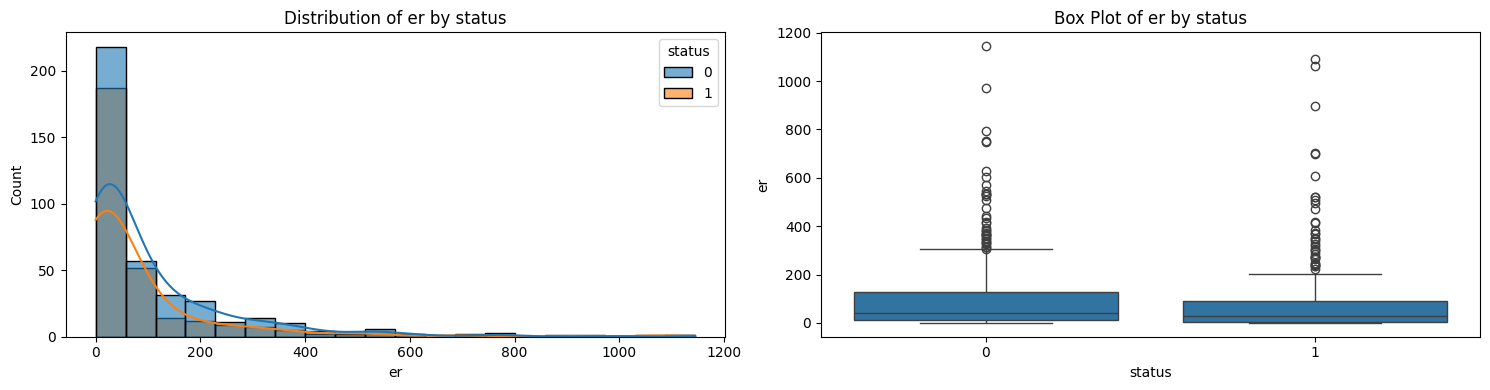

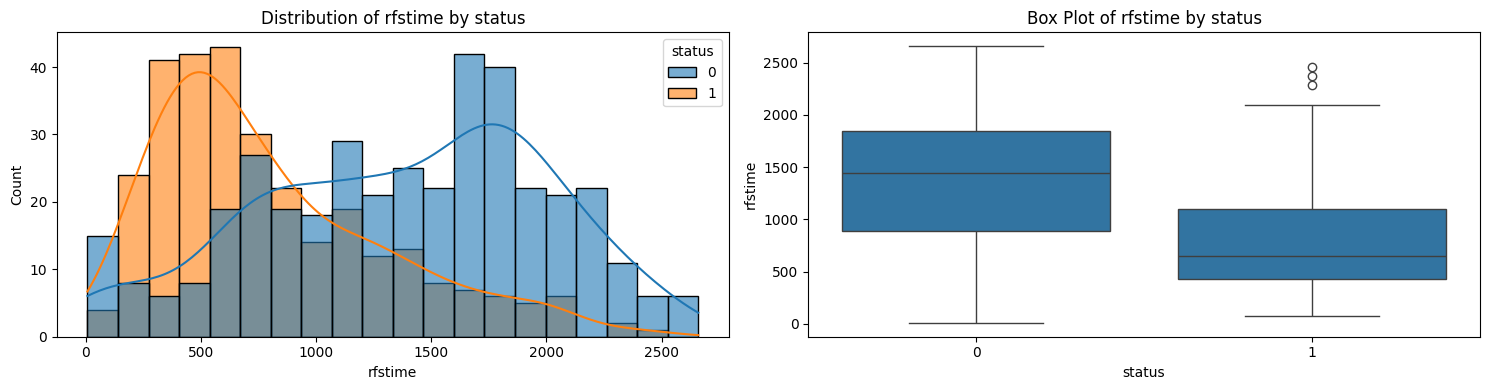

In [14]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms
    sns.histplot(data=df_gbsg, x=col, hue='status', kde=True, bins=20, alpha=0.6, ax=axes[0])
    axes[0].set_title(f"Distribution of {col} by status")
      
    # Plot 2: Box plots
    sns.boxplot(data=df_gbsg, x='status', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by status")
   
    plt.tight_layout()
    plt.show()

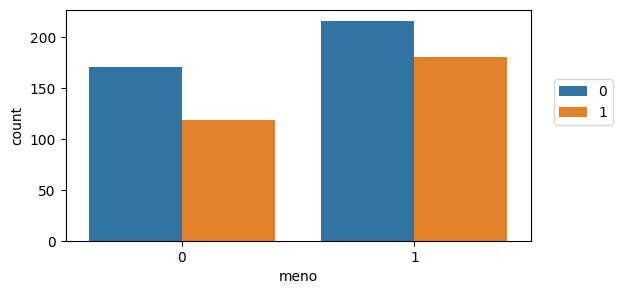

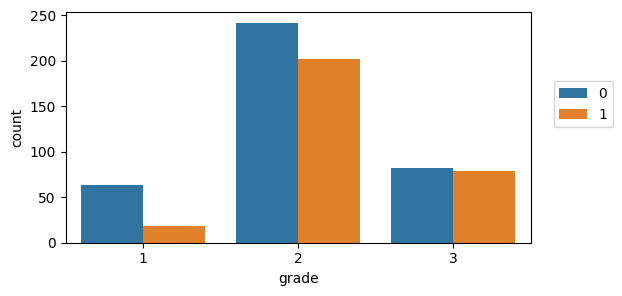

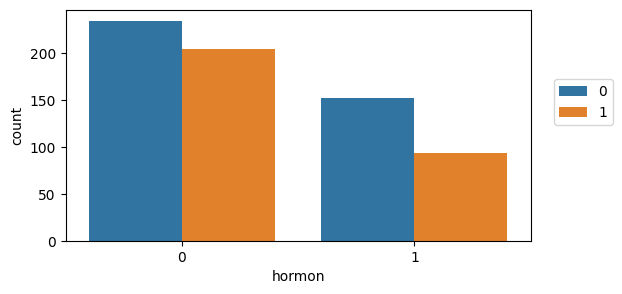

In [15]:
cols_qualitative = ['meno' ,'grade', 'hormon']

for col in cols_qualitative: 
    plt.figure(figsize=(6,3), dpi=100) 
    sns.countplot(data=df_gbsg,x=col,hue ='status') 
    plt.legend(loc=(1.05,0.5))

In [16]:
df_gbsg.corr()

,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status,log_nodes,log_pgr,log_er
age,1.000000,0.770076,-0.045412,-0.072318,0.032709,0.084355,0.323132,0.263906,0.053958,-0.004270,0.007447,0.035322,0.241715
meno,0.770076,1.000000,-0.042027,-0.036384,0.023169,0.018649,0.258860,0.276847,0.024712,0.044034,0.021938,-0.034820,0.192416
size,-0.045412,-0.042027,1.000000,0.103488,0.327665,-0.027415,-0.081766,-0.027456,-0.138376,0.130978,0.318336,-0.062029,-0.064246
grade,-0.072318,-0.036384,0.103488,1.000000,0.144187,-0.180905,-0.119663,-0.061001,-0.171505,0.131904,0.140752,-0.368936,-0.306216
nodes,0.032709,0.023169,0.327665,0.144187,1.000000,-0.072534,-0.043183,0.016382,-0.256751,0.242287,0.901278,-0.130874,-0.075857
pgr,0.084355,0.018649,-0.027415,-0.180905,-0.072534,1.000000,0.392601,0.052874,0.102729,-0.171596,-0.050293,0.651676,0.374911
er,0.323132,0.258860,-0.081766,-0.119663,-0.043183,0.392601,1.000000,0.144512,0.065477,-0.061561,-0.078564,0.355978,0.708340
hormon,0.263906,0.276847,-0.027456,-0.061001,0.016382,0.052874,0.144512,1.000000,0.134838,-0.081044,0.027562,0.018618,0.092795
rfstime,0.053958,0.024712,-0.138376,-0.171505,-0.256751,0.102729,0.065477,0.134838,1.000000,-0.447103,-0.270136,0.248380,0.154743
status,-0.004270,0.044034,0.130978,0.131904,0.242287,-0.171596,-0.061561,-0.081044,-0.447103,1.000000,0.273252,-0.215095,-0.131180


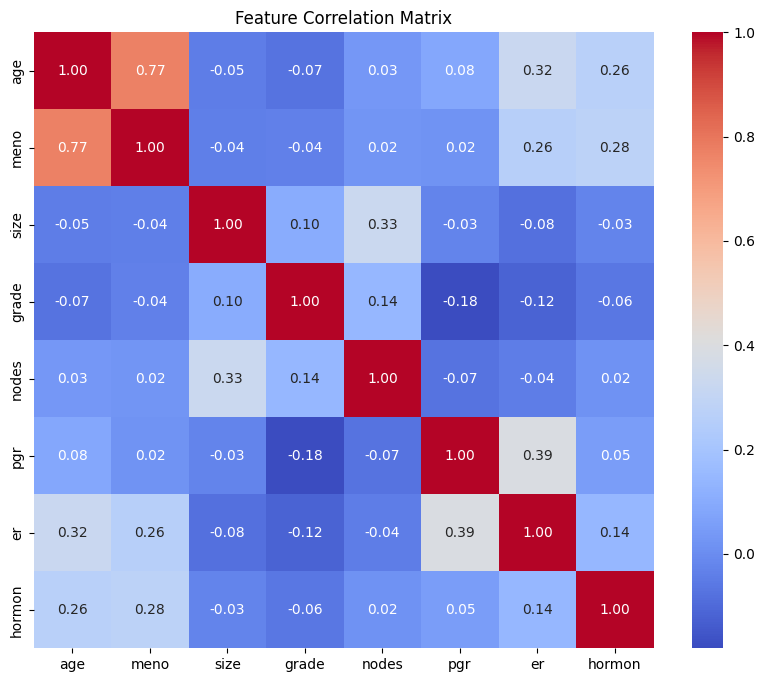

In [17]:
plt.figure(figsize=(10, 8))

# Compute correlation matrix
corr = df_gbsg.drop(['rfstime', 'status', 'log_nodes', 'log_pgr', 'log_er'], axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

#### gbsg modelling

In [18]:
T = df_gbsg['rfstime']
E = df_gbsg['status']

survival_table_from_events(T,E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,686,686
8.0,1,0,1,0,686
15.0,1,0,1,0,685
16.0,1,0,1,0,684
17.0,2,0,2,0,683
...,...,...,...,...,...
2551.0,1,0,1,0,5
2556.0,1,0,1,0,4
2563.0,1,0,1,0,3


In [19]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 686 total observations, 387 right-censored observations>

In [20]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
8.0,1.000000
15.0,1.000000
16.0,1.000000
17.0,1.000000
...,...
2551.0,0.342758
2556.0,0.342758
2563.0,0.342758


<Axes: xlabel='timeline'>

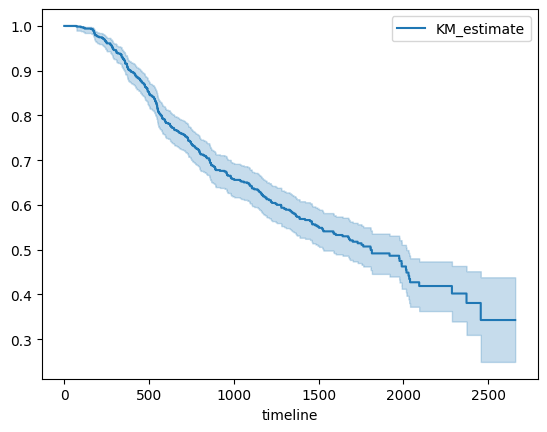

In [21]:
kmf.plot_survival_function()

In [22]:
wft = WeibullAFTFitter()
wft.fit(df_gbsg, duration_col='rfstime', event_col='status')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
   number of observations = 686
number of events observed = 299
           log-likelihood = -2564.27
         time fit was run = 2026-03-31 01:31:54 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age        0.01      1.01      0.01           -0.01            0.02                0.99                1.02
        er        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        grade     -0.13      0.88      0.08           -0.28            0.03                0.76                1.03
        hormon     0.29      1.33      0.09            0.11            0.46                1.11                1.59
        log_er     0.01      1.01      0.04           -0.07            0.09                0.93                1.09
        log_nodes -0.56      0.57      0.13           -0.82           -0.31                0.44                0.73
        log_pgr    0.09      1.10      0.04            0.02            0.17                1.02                1.19
        meno      -0.14      0.87      0.13           -0.40            0.11                0.67                1.11
        nodes      0.01      1.01      0.01           -0.02            0.04                0.98                1.04
        pgr        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        size      -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
        Intercept  8.15   3454.83      0.39            7.38            8.92             1602.23             7449.54
rho_    Intercept  0.35      1.42      0.05            0.26            0.45                1.29                1.56

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00  0.95   0.34      1.55
        er           0.00 -1.31   0.19      2.40
        grade        0.00 -1.59   0.11      3.17
        hormon       0.00  3.16 <0.005      9.29
        log_er       0.00  0.24   0.81      0.30
        log_nodes    0.00 -4.38 <0.005     16.38
        log_pgr      0.00  2.35   0.02      5.73
        meno         0.00 -1.13   0.26      1.96
        nodes        0.00  0.81   0.42      1.27
        pgr          0.00  1.53   0.13      2.99
        size         0.00 -1.12   0.26      1.92
        Intercept    0.00 20.78 <0.005    316.27
rho_    Intercept    0.00  7.27 <0.005     41.38
---
Concordance = 0.70
AIC = 5154.54
log-likelihood ratio test = 146.02 on 11 df
-log2(p) of ll-ratio test = 83.09

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

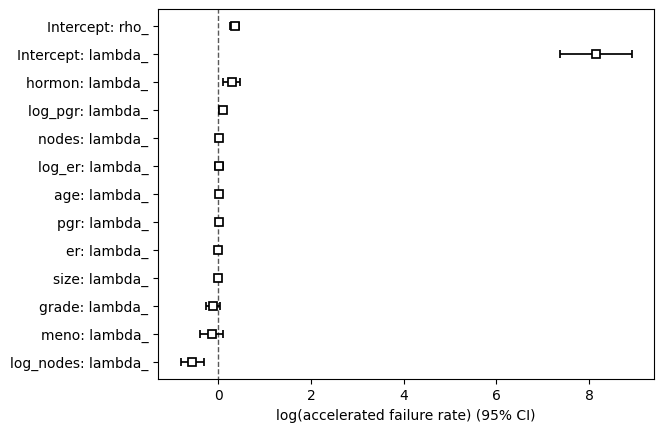

In [23]:
wft.plot()

In [24]:
features = ['log_nodes', 'log_pgr', 'log_er', 'age', 'meno', 'size', 'grade', 'hormon', 'rfstime', 'status']

In [25]:
# saving the dataframe
df_gbsg[features].to_csv(r'./data/preprocess-data/preprocess_gbsg.csv')

In [26]:
cph = CoxPHFitter()
cph.fit(df_gbsg[features], duration_col='rfstime', event_col='status', strata=['meno' ,'grade', 'hormon'])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
                   strata = ['meno', 'grade', 'hormon']
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1118.90
         time fit was run = 2026-03-31 01:31:56 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
log_nodes  0.59      1.80      0.08            0.42            0.75                1.52                2.12
log_pgr   -0.19      0.83      0.04           -0.27           -0.11                0.76                0.90
log_er     0.03      1.03      0.04           -0.06            0.11                0.95                1.12
age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
size       0.01      1.01      0.00           -0.00            0.01                1.00                1.01

           cmp to     z      p  -log2(p)
covariate                               
log_nodes    0.00  6.99 <0.005     38.45
log_pgr      0.00 -4.55 <0.005     17.51
log_er       0.00  0.68   0.50      1.01
age          0.00 -0.82   0.41      1.29
size         0.00  1.33   0.18      2.45
---
Concordance = 0.67
Partial AIC = 2247.80
log-likelihood ratio test = 95.54 on 5 df
-log2(p) of ll-ratio test = 60.92


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
         test_name = proportional_hazard_test

---
                test_statistic      p  -log2(p)
age       km              2.41   0.12      3.05
          rank            9.73 <0.005      9.11
log_er    km              2.07   0.15      2.74
          rank            0.31   0.58      0.80
log_nodes km              0.57   0.45      1.15
          rank            0.32   0.57      0.81
log_pgr   km              0.09   0.76      0.40
          rank            0.32   0.57      0.81
size      km              0.03   0.85      0.23
          rank            0.04   0.85      0.24



1. Variable 'age' failed the non-proportional test: p-value is 0.0018.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Propor

[[<Axes: xlabel='rank-transformed time\n(p=0.5707)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4514)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5694)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7592)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5763)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1500)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0018)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1204)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8494)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8516)'>]]

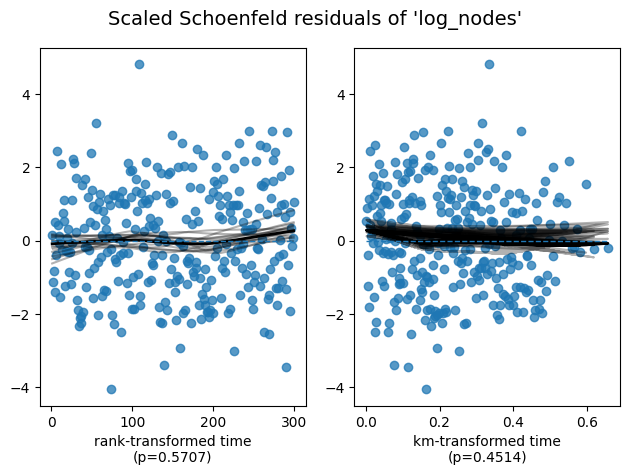

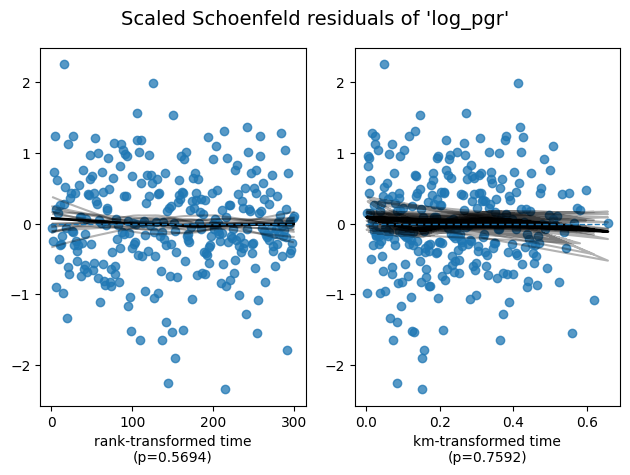

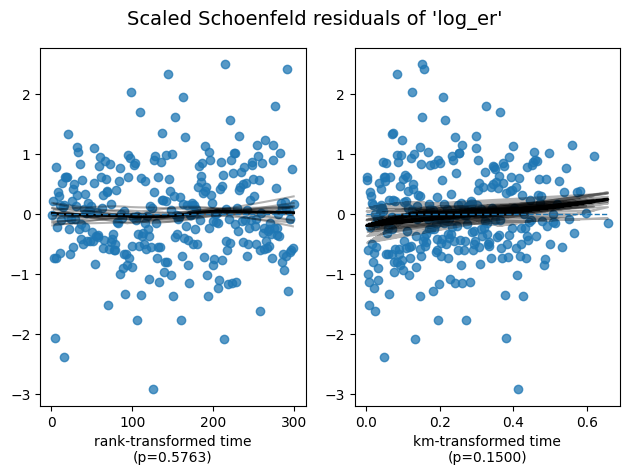

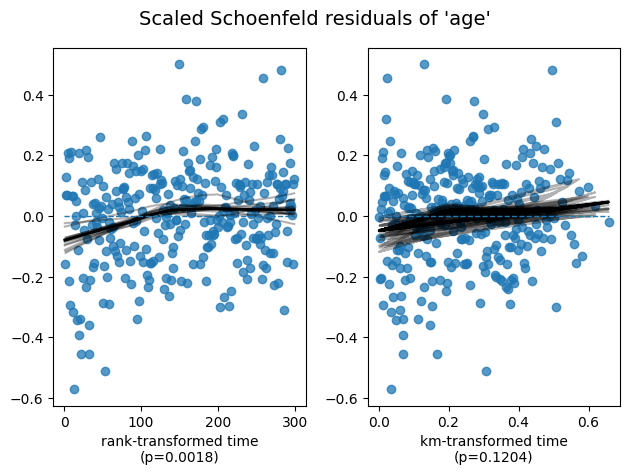

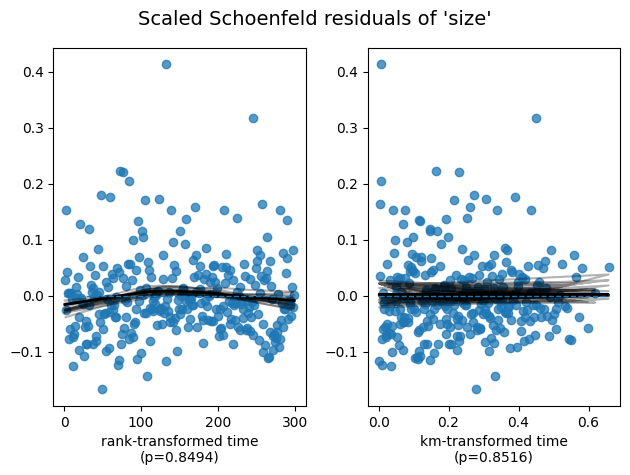

In [27]:
cph.check_assumptions(df_gbsg[features], show_plots=True, p_value_threshold=0.05)

In [28]:
scores = k_fold_cross_validation(
    cph, df_gbsg[features], duration_col='rfstime', event_col='status', k=5,
    scoring_method='concordance_index'
)

print("Average C-index:", np.mean(scores))

c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index i

Average C-index: 0.6797468240590471


c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


In [29]:
pred = cph.predict_partial_hazard(df_gbsg)
c_index_gbsg = concordance_index(df_gbsg["rfstime"], -pred, df_gbsg["status"])
print("CoxPH C-index:", c_index_gbsg)

CoxPH C-index: 0.6870716604544908


In [30]:
ibs_gbsg = compute_ibs(
    cph=cph,
    df=df_gbsg,
    duration_col="rfstime",
    event_col="status"
)

print("CoxPH IBS:", ibs_gbsg)

CoxPH IBS: 0.22749266325434137


In [31]:
# AIC score
print("AIC:", cph.AIC_partial_)

AIC: 1689.7577164345425


In [32]:
log_likelihood = cph.log_likelihood_
k = len(cph.params_)
n = cph._n_examples

bic = -2 * log_likelihood + k * np.log(n)

print("BIC:", bic)

BIC: 1711.2982086420902


### Haberman

In [33]:
df_hm.shape

(305, 4)

In [34]:
df_hm.head(10).transpose()

,0,1,2,3,4,5,6,7,8,9
30,30,30,31,31,33,33,34,34,34,34
64,62,65,59,65,58,60,59,66,58,60
1,3,0,2,4,10,0,0,9,30,1
1.1,1,1,1,1,1,1,2,2,1,1


In [35]:
df_hm.isna().sum()

30     0
64     0
1      0
1.1    0
dtype: int64

In [36]:
df_hm.columns = ["PatientAge", "PatientYearOperation", "NumberAxillaryNodes", "SurvivalStatus"] # give name to columns
df_hm.head(5)

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [37]:
df_hm.describe()

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,4.036066,1.265574
std,10.744024,3.254078,7.199370,0.442364
min,30.000000,58.000000,0.000000,1.000000
25%,44.000000,60.000000,0.000000,1.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,61.000000,66.000000,4.000000,2.000000
max,83.000000,69.000000,52.000000,2.000000


In [38]:
df_hm["SurvivalStatus"] = np.where(df_hm["SurvivalStatus"] == 2, 1, 0)

# IMPORTANT NOTE: The Haberman dataset lacks a continuous time-to-event variable.
# It only records whether patients survived 5+ years (binary outcome).
# This makes it fundamentally unsuitable for Cox PH modeling, which requires
# actual time-to-event data. For research purposes, we construct a synthetic
# duration: censored patients get duration=5 (survived full window),
# event patients get a duration slightly less than 5 (died within window).
# This is an approximation. Consider replacing with a dataset that has proper
# time-to-event data for rigorous analysis.

np.random.seed(42)
df_hm["Duration"] = np.where(
    df_hm["SurvivalStatus"] == 1,
    np.random.uniform(0.5, 4.99, size=len(df_hm)),  # events: died within 5 years
    5.0  # censored: survived 5+ years
)

In [39]:
print(df_hm["SurvivalStatus"].value_counts())

print("\nIn Percentage:")
print(df_hm['SurvivalStatus'].value_counts(normalize = True) )

SurvivalStatus
0    224
1     81
Name: count, dtype: int64

In Percentage:
SurvivalStatus
0    0.734426
1    0.265574
Name: proportion, dtype: float64


In [40]:
event_rate = df_hm["SurvivalStatus"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")


Event rate: 0.27
Censoring rate: 0.73


In [41]:
df_hm['LogNodes'] = np.log1p(df_hm['NumberAxillaryNodes'])

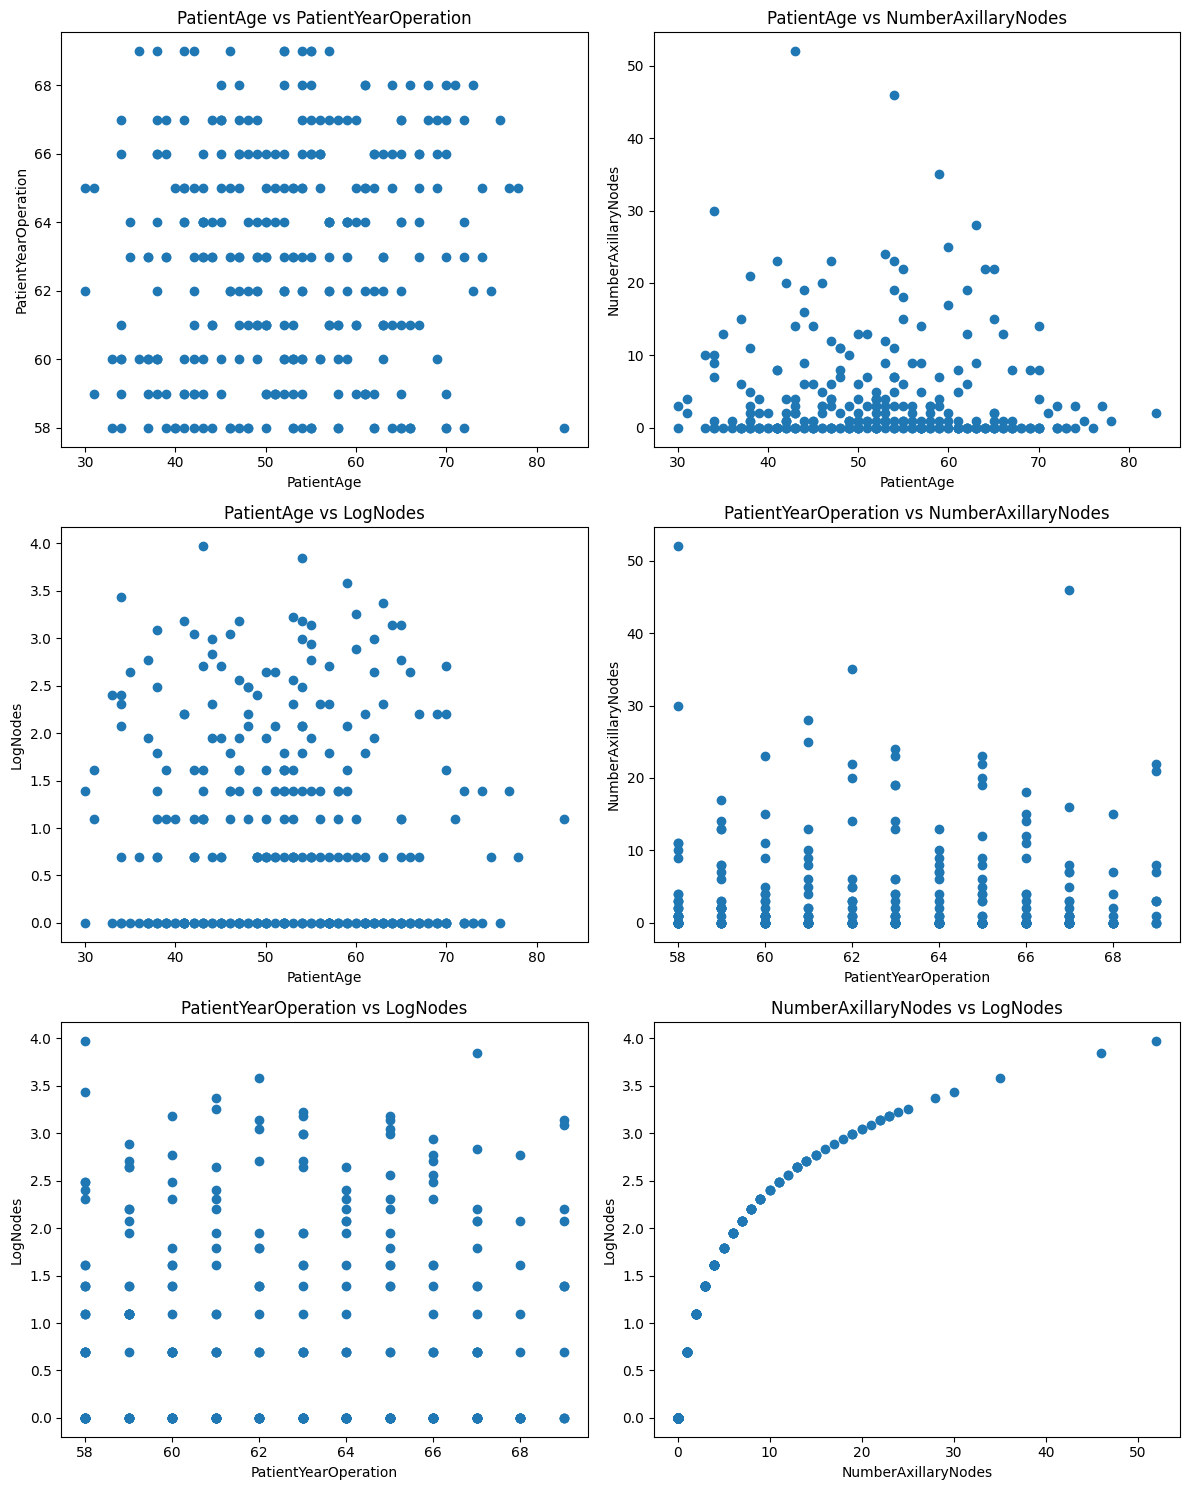

In [42]:
cols = ['PatientAge', 'PatientYearOperation', 'NumberAxillaryNodes', 'LogNodes']

pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

# Two plots per row
n_cols = 2
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()  # make indexing easy

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_hm[x], df_hm[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

# Hide any unused subplots
for ax in axes[len(pairs):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

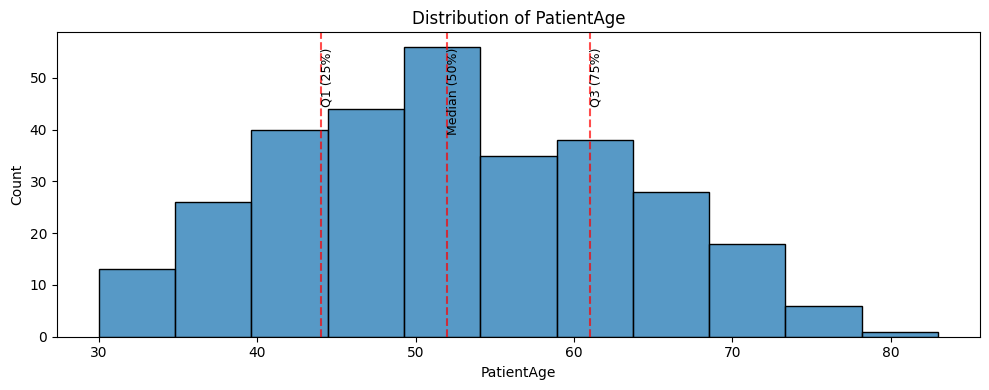

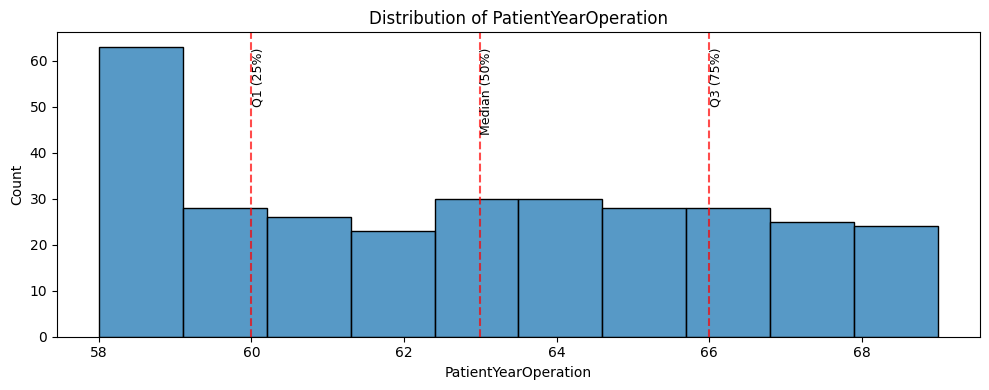

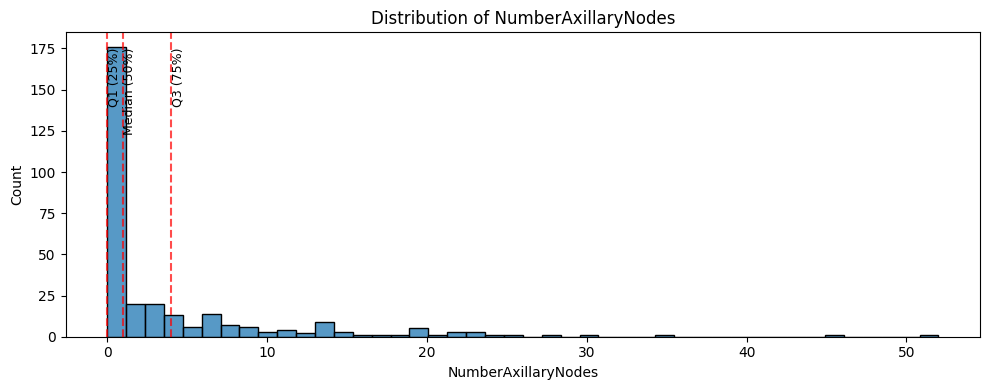

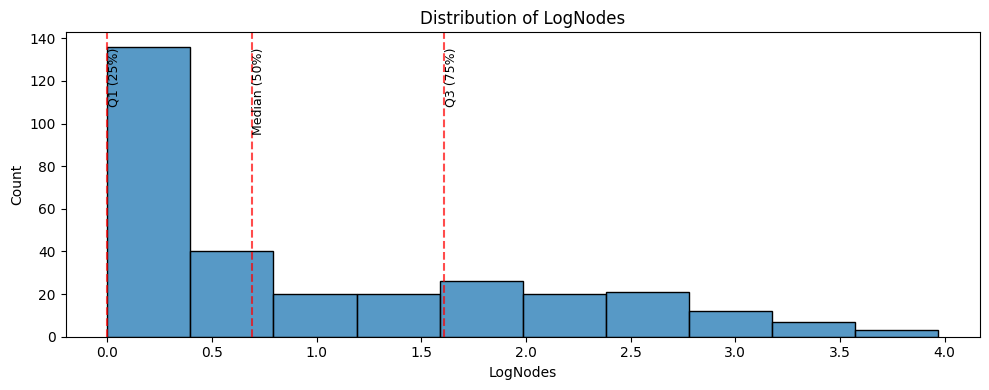

In [43]:
for col in cols:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
   
    # Overlapping histogram with quantiles
    sns.histplot(data=df_hm, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    
    # Add quantile lines (25th, 50th, 75th percentiles)
    quantiles = df_hm[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        ax.axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.text(q_val, ax.get_ylim()[1]*0.95, label, 
                rotation=90, verticalalignment='top', fontsize=9)
   
    plt.tight_layout()
    plt.show()

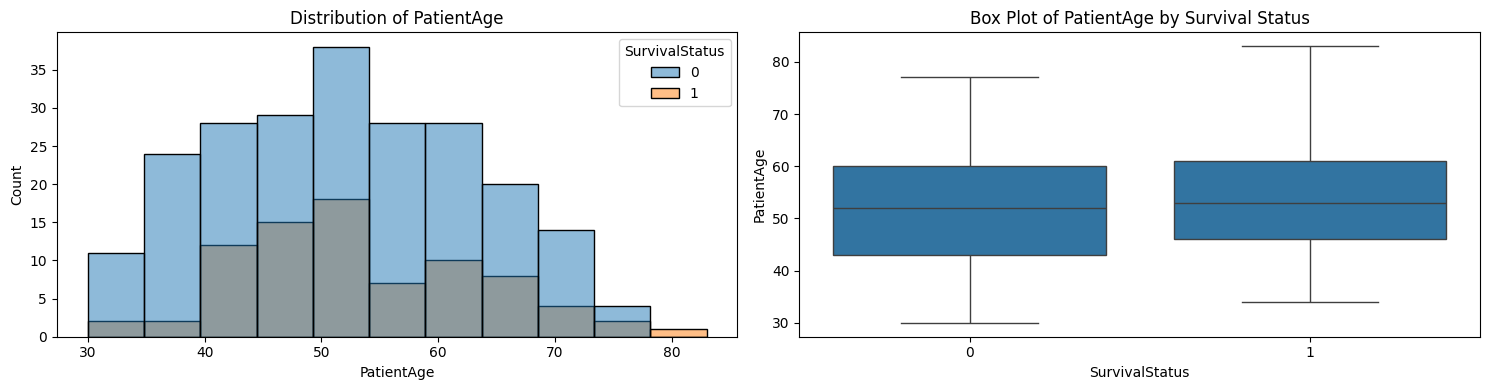

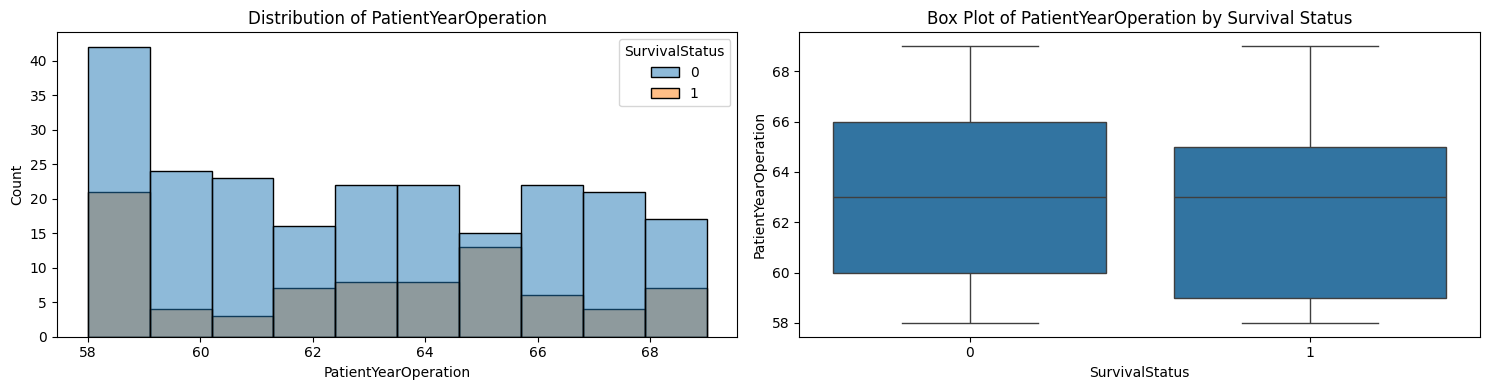

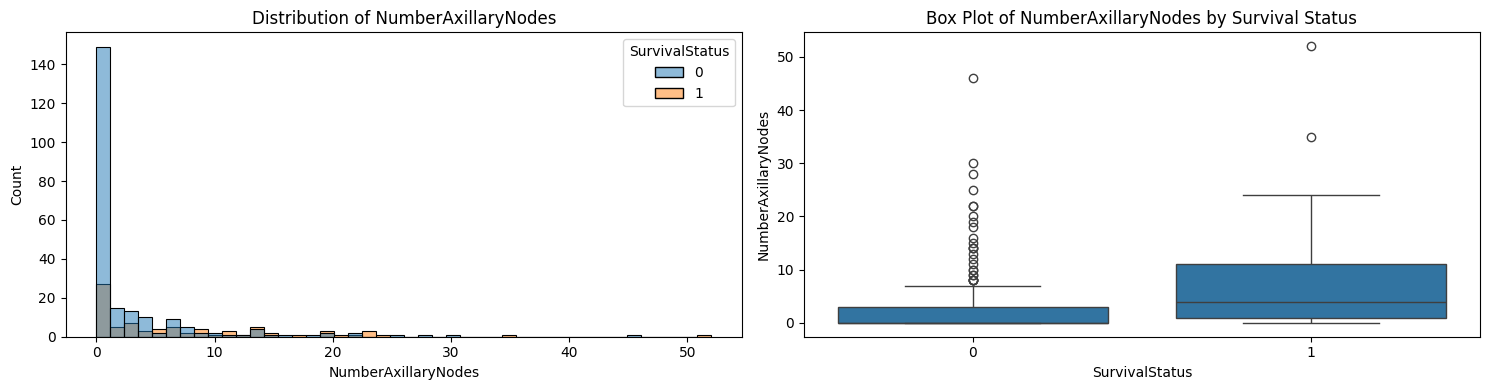

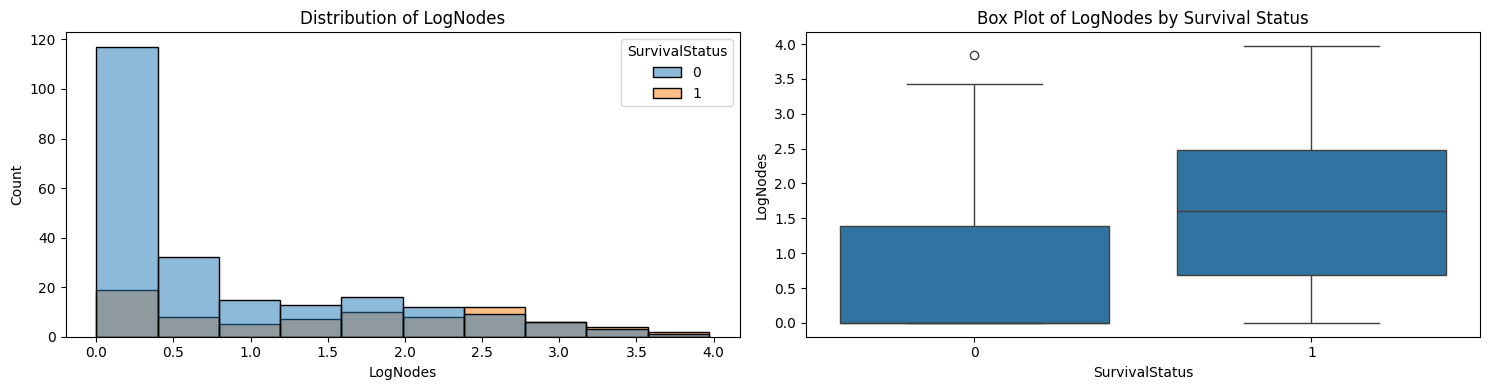

In [44]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms
    sns.histplot(data=df_hm, x=col, ax=axes[0], hue='SurvivalStatus')
    axes[0].set_title(f"Distribution of {col}")
   
    # Plot 2: Box plot by survival status
    sns.boxplot(data=df_hm, x='SurvivalStatus', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by Survival Status")
   
    plt.tight_layout()
    plt.show()

In [45]:
df_hm.corr().abs()

,PatientAge,PatientYearOperation,NumberAxillaryNodes,SurvivalStatus,Duration,LogNodes
PatientAge,1.000000,0.092623,0.066548,0.064351,0.033454,0.097061
PatientYearOperation,0.092623,1.000000,0.003277,0.004076,0.013938,0.016857
NumberAxillaryNodes,0.066548,0.003277,1.000000,0.286191,0.314475,0.868229
SurvivalStatus,0.064351,0.004076,0.286191,1.000000,0.830618,0.337705
Duration,0.033454,0.013938,0.314475,0.830618,1.000000,0.362764
LogNodes,0.097061,0.016857,0.868229,0.337705,0.362764,1.000000


> **Note:** The Haberman dataset contains only a binary 5-year survival outcome with no continuous time-to-event variable. It is therefore **not suitable for Cox PH modelling**, which fundamentally requires ordered event times for partial likelihood estimation. The EDA above is retained for exploratory purposes. For Cox PH modelling, we use the **PBC (Primary Biliary Cholangitis)** dataset instead.

### PBC (Primary Biliary Cholangitis) - Mayo Clinic

In [46]:
df_pbc.shape

(418, 20)

In [47]:
df_pbc.head(10)

,id,time,status,trt,age,sex,ascites,hepato,spiders,edema,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage
0,1,400,2,1.0,58.765229,f,1.0,1.0,1.0,1.0,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,0,1.0,56.446270,f,0.0,1.0,1.0,0.0,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,2,1.0,70.072553,m,0.0,0.0,0.0,0.5,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,2,1.0,54.740589,f,0.0,1.0,1.0,0.5,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,1,2.0,38.105407,f,0.0,1.0,1.0,0.0,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,2,2.0,66.258727,f,0.0,1.0,0.0,0.0,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,0,2.0,55.534565,f,0.0,1.0,0.0,0.0,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,2,2.0,53.056810,f,0.0,0.0,0.0,0.0,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,2,1.0,42.507871,f,0.0,0.0,1.0,0.0,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,2,2.0,70.559890,f,1.0,0.0,1.0,1.0,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


In [48]:
df_pbc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        418 non-null    int64  
 1   time      418 non-null    int64  
 2   status    418 non-null    int64  
 3   trt       312 non-null    float64
 4   age       418 non-null    float64
 5   sex       418 non-null    object 
 6   ascites   312 non-null    float64
 7   hepato    312 non-null    float64
 8   spiders   312 non-null    float64
 9   edema     418 non-null    float64
 10  bili      418 non-null    float64
 11  chol      284 non-null    float64
 12  albumin   418 non-null    float64
 13  copper    310 non-null    float64
 14  alk.phos  312 non-null    float64
 15  ast       312 non-null    float64
 16  trig      282 non-null    float64
 17  platelet  407 non-null    float64
 18  protime   416 non-null    float64
 19  stage     412 non-null    float64
dtypes: float64(16), int64(3), object

In [49]:
df_pbc.isna().sum()

id            0
time          0
status        0
trt         106
age           0
sex           0
ascites     106
hepato      106
spiders     106
edema         0
bili          0
chol        134
albumin       0
copper      108
alk.phos    106
ast         106
trig        136
platelet     11
protime       2
stage         6
dtype: int64

#### PBC data preprocessing

In [50]:
# Drop 'id' column (not a prognostic variable)
df_pbc = df_pbc.drop('id', axis=1)

# status: 0=censored, 1=transplant, 2=dead
# For survival analysis: treat death (2) as the event, censor transplant (1) and alive (0)
df_pbc['status_binary'] = (df_pbc['status'] == 2).astype(int)

# trt: 1=D-penicillamine, 2=placebo, NaN=not randomised
# Fill NaN with 0 (not randomised) and convert to categorical indicator
df_pbc['trt'] = df_pbc['trt'].fillna(0).astype(int)

# sex: convert to binary (0=male, 1=female) if string
if df_pbc['sex'].dtype == 'object':
    df_pbc['sex'] = (df_pbc['sex'] == 'f').astype(int)

# edema: 0=no edema, 0.5=untreated/successfully treated, 1=edema despite diuretics
# Keep as numeric

# stage: histologic stage 1-4 (treat as ordinal/categorical)
# Keep as numeric for now

print("Status distribution (original):")
print(df_pbc['status'].value_counts().sort_index())
print("\nBinary status (0=censored/transplant, 1=dead):")
print(df_pbc['status_binary'].value_counts().sort_index())

Status distribution (original):
status
0    232
1     25
2    161
Name: count, dtype: int64

Binary status (0=censored/transplant, 1=dead):
status_binary
0    257
1    161
Name: count, dtype: int64


In [51]:
# Handle missing values
print("Missing values before imputation:")
print(df_pbc.isna().sum()[df_pbc.isna().sum() > 0])

# For continuous variables with missing values, impute with median
cols_to_impute = df_pbc.columns[df_pbc.isna().any()].tolist()
for col in cols_to_impute:
    if df_pbc[col].dtype in ['float64', 'int64']:
        median_val = df_pbc[col].median()
        df_pbc[col] = df_pbc[col].fillna(median_val)
        print(f"  {col}: imputed {df_pbc[col].isna().sum()} remaining NaN with median={median_val:.2f}")

# Drop rows where stage is missing (categorical, can't impute meaningfully)
if 'stage' in cols_to_impute:
    df_pbc = df_pbc.dropna(subset=['stage'])
    df_pbc['stage'] = df_pbc['stage'].astype(int)

print("\nMissing values after imputation:")
print(df_pbc.isna().sum().sum(), "total missing values")

Missing values before imputation:
ascites     106
hepato      106
spiders     106
chol        134
copper      108
alk.phos    106
ast         106
trig        136
platelet     11
protime       2
stage         6
dtype: int64
  ascites: imputed 0 remaining NaN with median=0.00
  hepato: imputed 0 remaining NaN with median=1.00
  spiders: imputed 0 remaining NaN with median=0.00
  chol: imputed 0 remaining NaN with median=309.50
  copper: imputed 0 remaining NaN with median=73.00
  alk.phos: imputed 0 remaining NaN with median=1259.00
  ast: imputed 0 remaining NaN with median=114.70
  trig: imputed 0 remaining NaN with median=108.00
  platelet: imputed 0 remaining NaN with median=251.00
  protime: imputed 0 remaining NaN with median=10.60
  stage: imputed 0 remaining NaN with median=3.00

Missing values after imputation:
0 total missing values


In [52]:
print(df_pbc["status_binary"].value_counts())

print("\nIn Percentage:")
print(df_pbc['status_binary'].value_counts(normalize=True))

status_binary
0    257
1    161
Name: count, dtype: int64

In Percentage:
status_binary
0    0.614833
1    0.385167
Name: proportion, dtype: float64


In [53]:
event_rate = df_pbc["status_binary"].mean()
censor_rate = 1 - event_rate

print(f"Event rate (death): {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")

Event rate (death): 0.39
Censoring rate: 0.61


In [54]:
df_pbc.describe()

,time,status,trt,age,sex,ascites,hepato,spiders,edema,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage,status_binary
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1917.782297,0.830144,1.114833,50.741551,0.894737,0.057416,0.636364,0.215311,0.100478,3.220813,350.272727,3.497440,91.279904,1799.144976,120.564067,119.267943,256.866029,10.731100,3.023923,0.385167
std,1104.672992,0.955785,0.781206,10.447214,0.307260,0.232915,0.481622,0.411530,0.253417,4.407506,193.123893,0.424972,74.485481,1875.121982,49.085094,54.050691,97.024861,1.019587,0.875678,0.487218
min,41.000000,0.000000,0.000000,26.277892,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000,0.000000
25%,1092.750000,0.000000,0.000000,42.832307,1.000000,0.000000,0.000000,0.000000,0.000000,0.800000,273.000000,3.242500,51.250000,1016.250000,91.000000,95.000000,190.000000,10.000000,2.000000,0.000000
50%,1730.000000,0.000000,1.000000,51.000684,1.000000,0.000000,1.000000,0.000000,0.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000,0.000000
75%,2613.500000,2.000000,2.000000,58.240931,1.000000,0.000000,1.000000,0.000000,0.000000,3.400000,347.750000,3.770000,100.750000,1707.750000,135.750000,127.750000,315.500000,11.100000,4.000000,1.000000
max,4795.000000,2.000000,2.000000,78.439425,1.000000,1.000000,1.000000,1.000000,1.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000,1.000000


#### PBC continuous variable distributions

In [55]:
# Log-transform skewed biomarkers
# bili, chol, copper, alk.phos, ast, trig have strong right-skew
df_pbc['log_bili'] = np.log1p(df_pbc['bili'])
df_pbc['log_copper'] = np.log1p(df_pbc['copper'])
df_pbc['log_alkphos'] = np.log1p(df_pbc['alk.phos'])
df_pbc['log_ast'] = np.log1p(df_pbc['ast'])
df_pbc['log_trig'] = np.log1p(df_pbc['trig'])
df_pbc['log_chol'] = np.log1p(df_pbc['chol'])
df_pbc['log_platelet'] = np.log1p(df_pbc['platelet'])

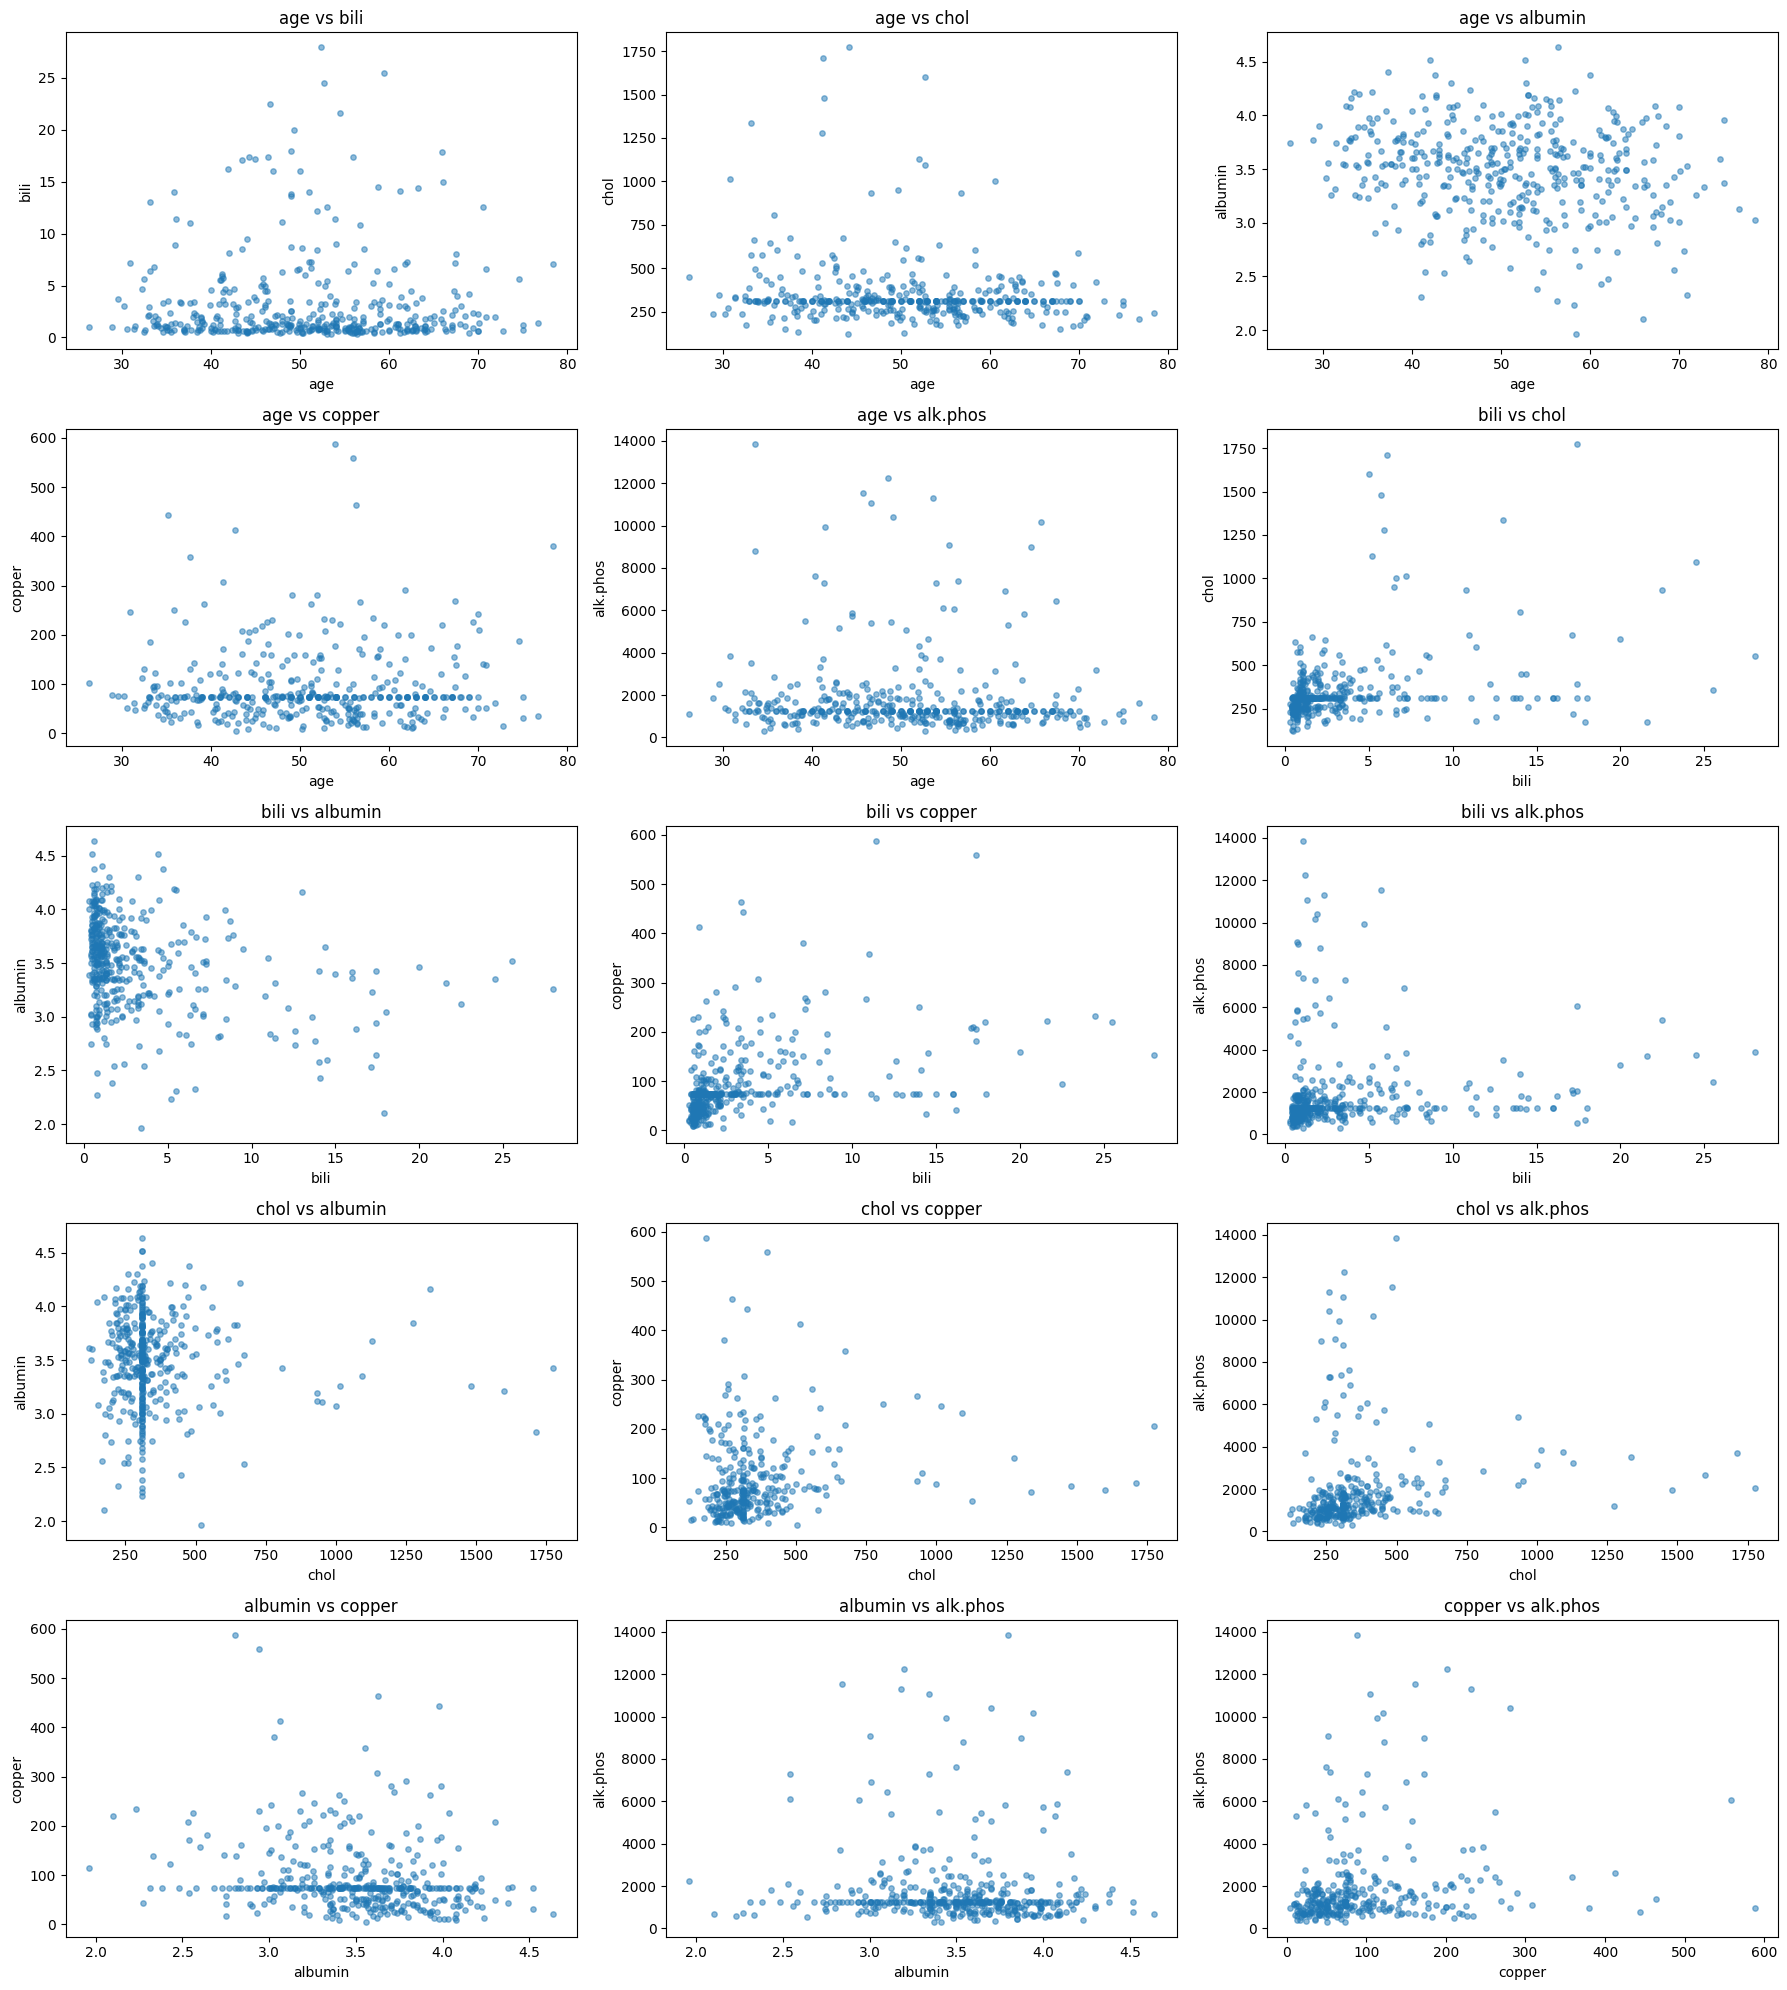

In [56]:
cols_continuous = ['age', 'bili', 'chol', 'albumin', 'copper', 'alk.phos', 'ast', 'trig', 'platelet', 'protime', 'time']

pairs = list(itertools.combinations(cols_continuous[:6], 2))
n = len(pairs)
cols_grid = 3
rows_grid = math.ceil(n / cols_grid)

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(6*cols_grid, 4*rows_grid))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_pbc[x], df_pbc[y], alpha=0.5, s=15)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

for i in range(len(pairs), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

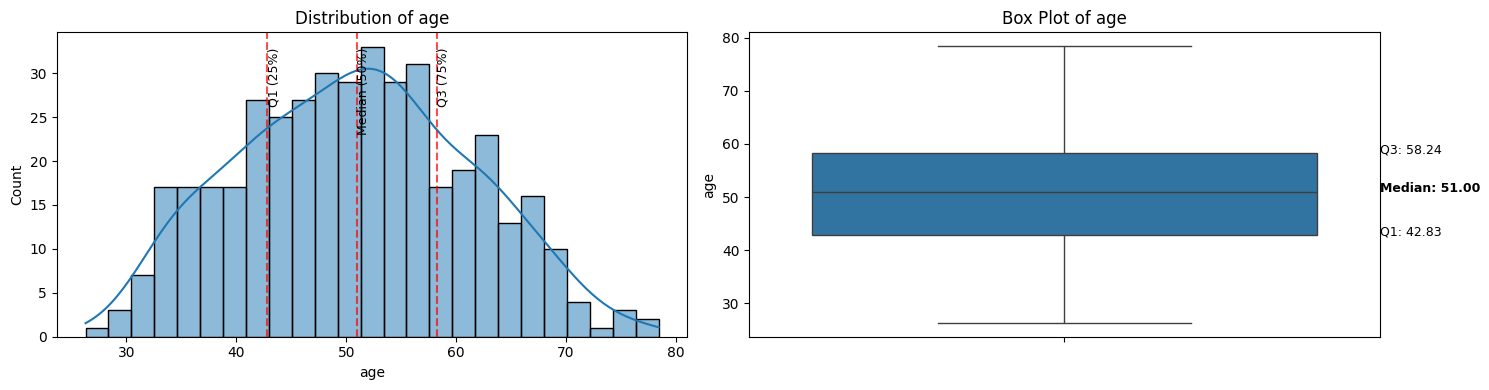

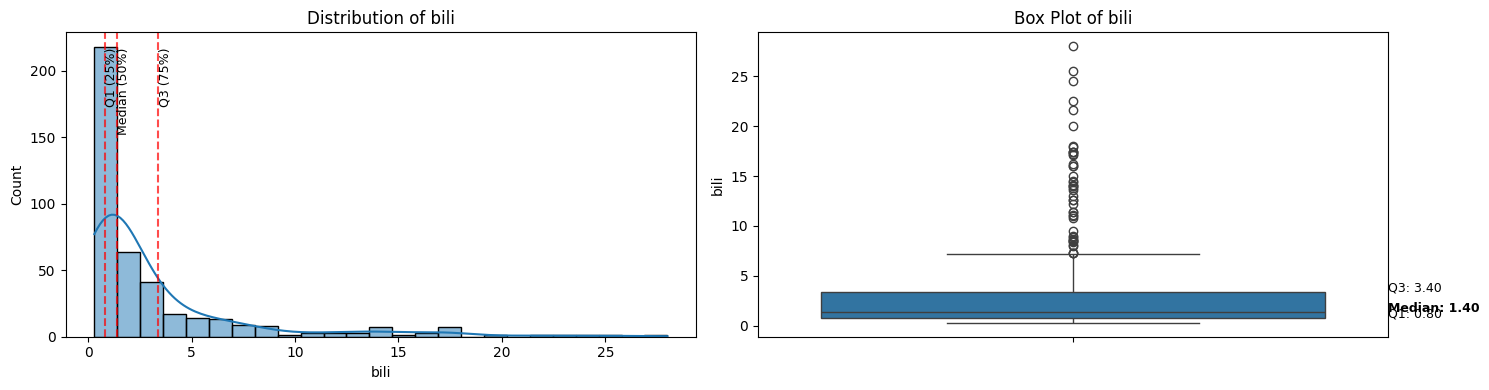

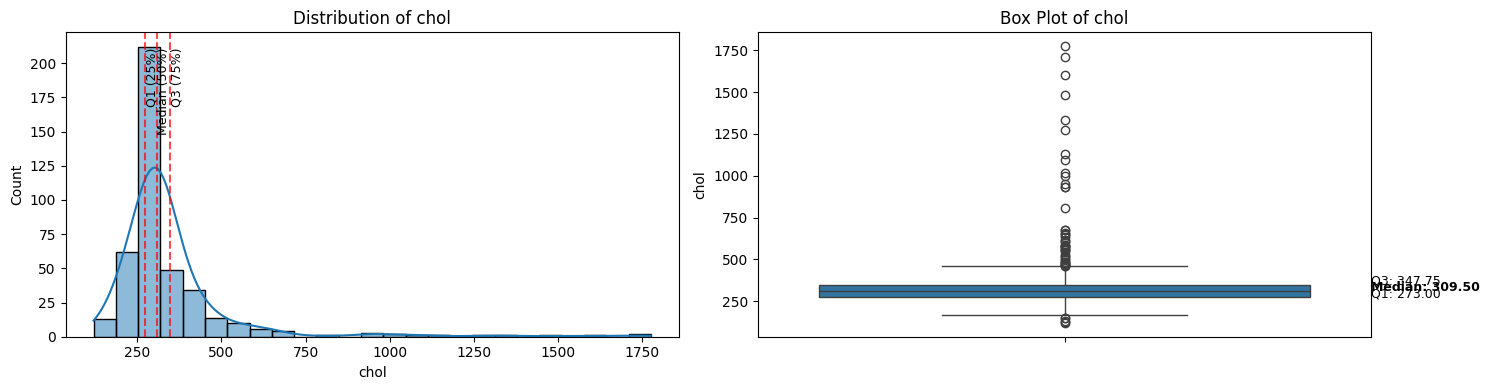

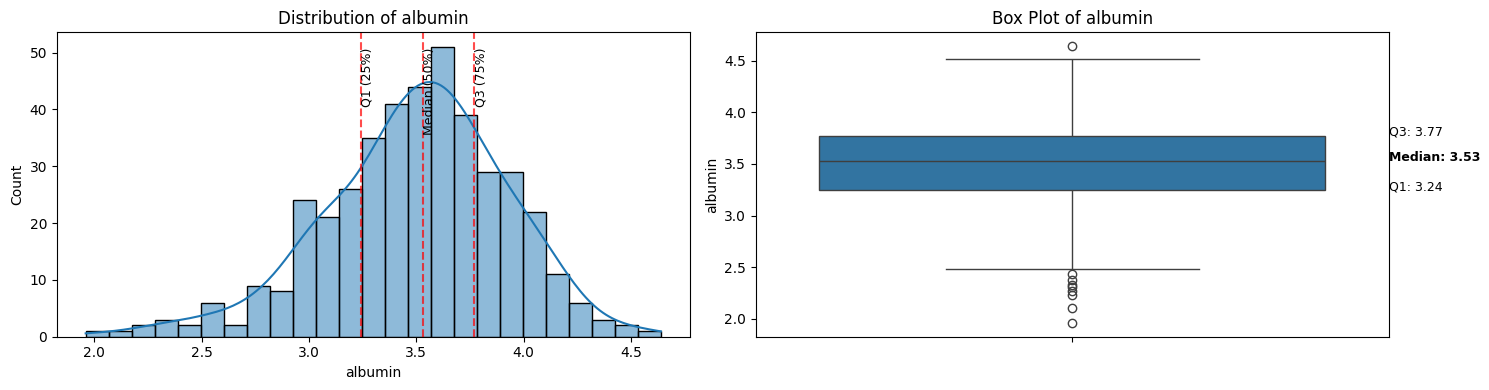

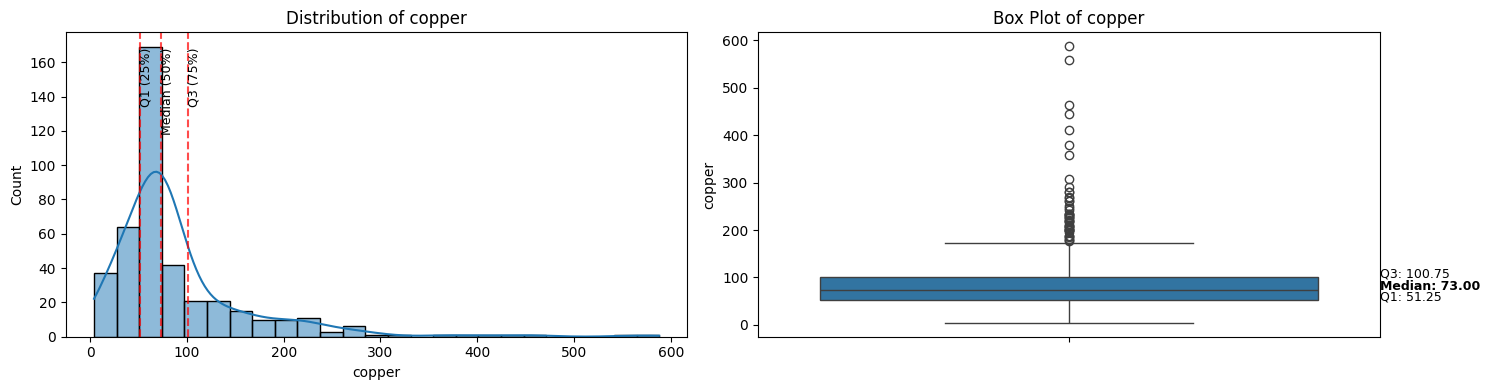

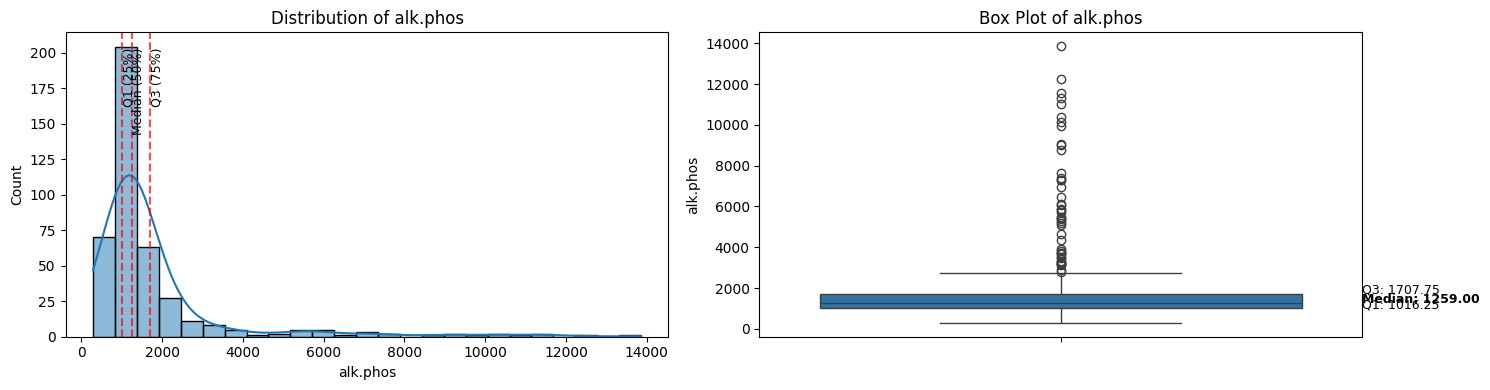

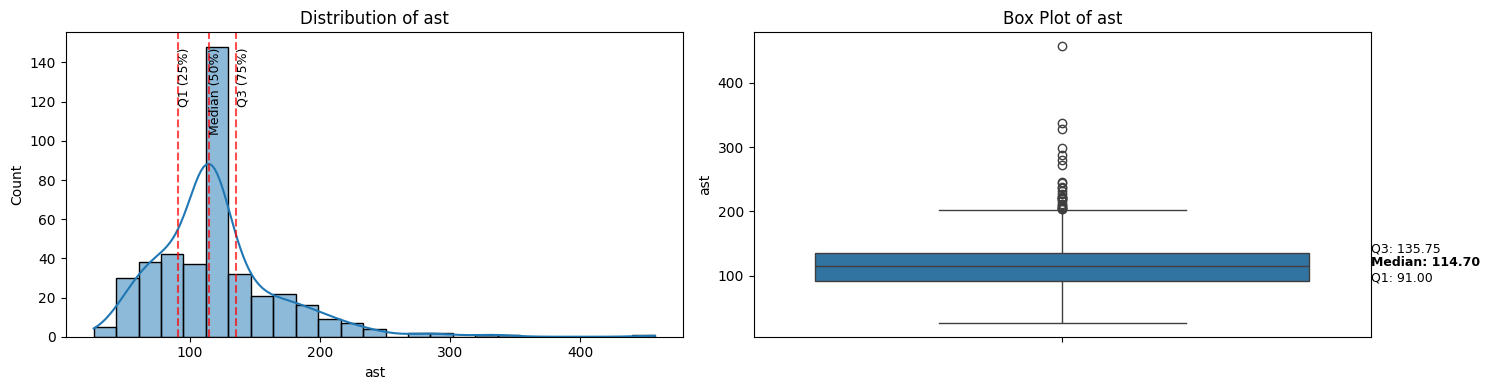

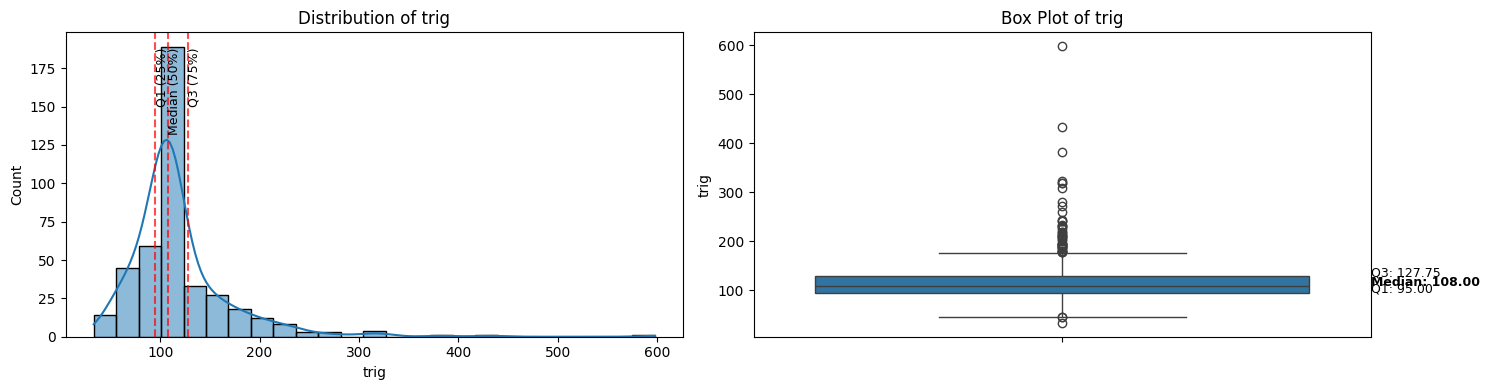

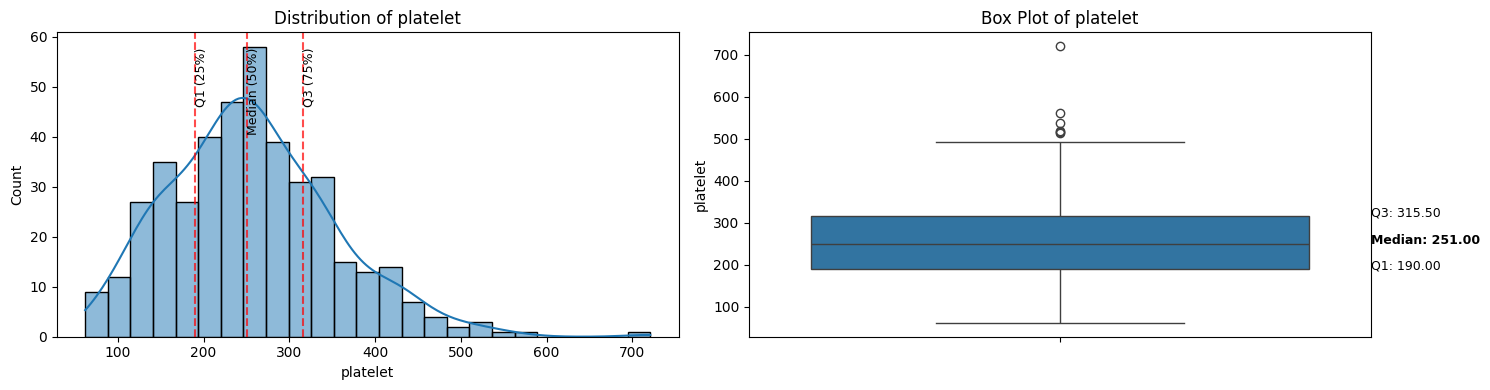

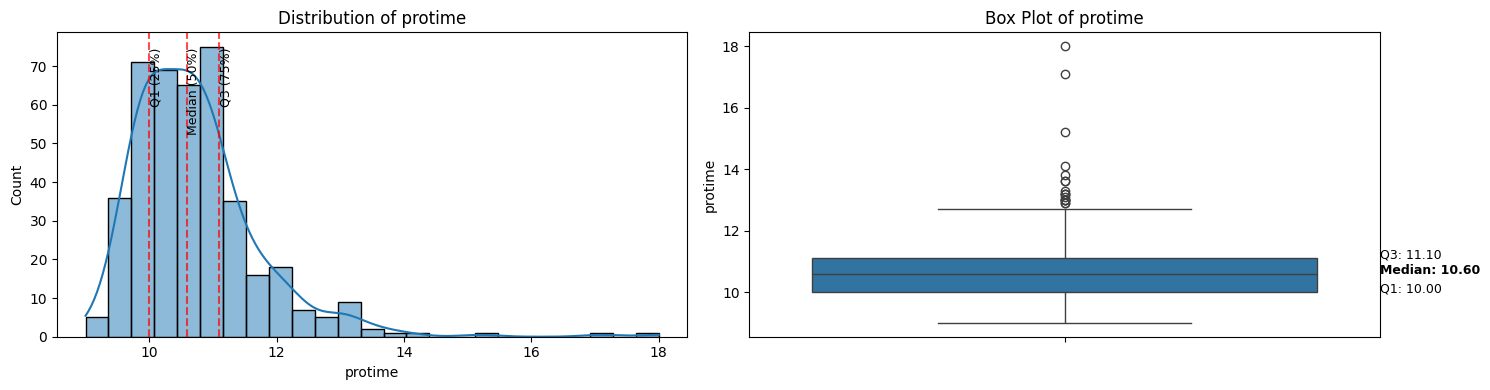

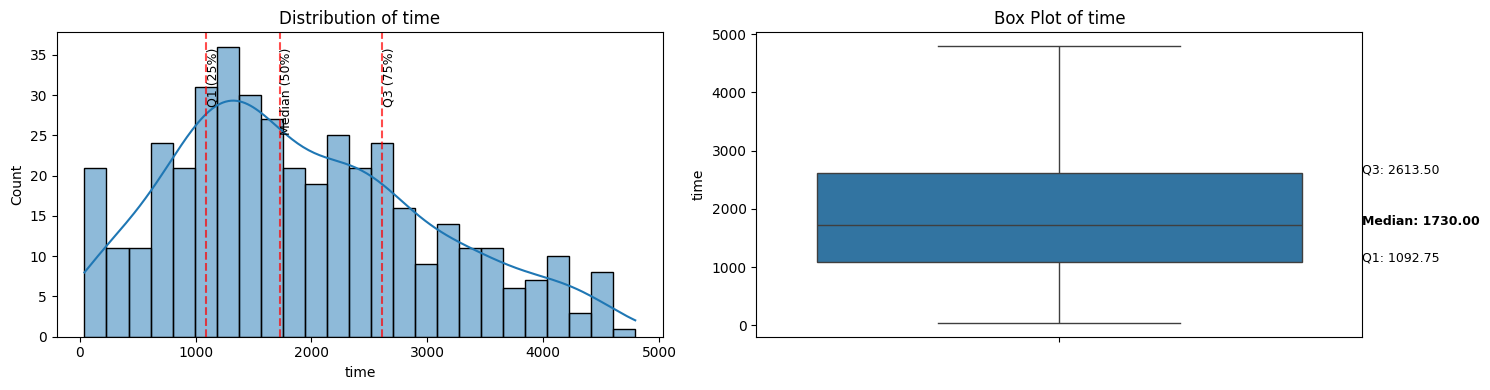

In [57]:
for col in cols_continuous:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Histogram with quantiles
    sns.histplot(data=df_pbc, x=col, kde=True, bins=25, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    quantiles = df_pbc[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
      
    # Plot 2: Box plot
    sns.boxplot(data=df_pbc, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    q1, median, q3 = df_pbc[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

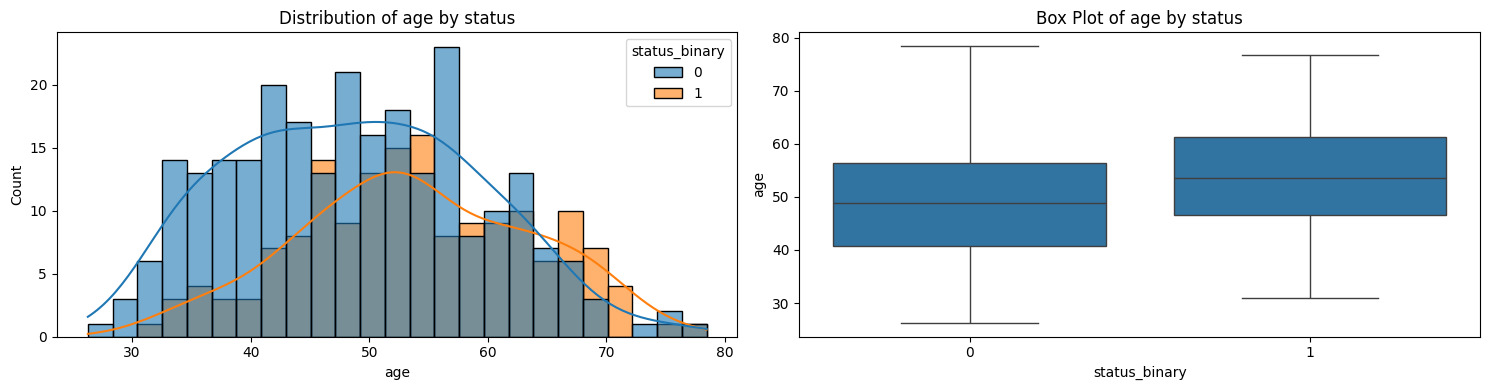

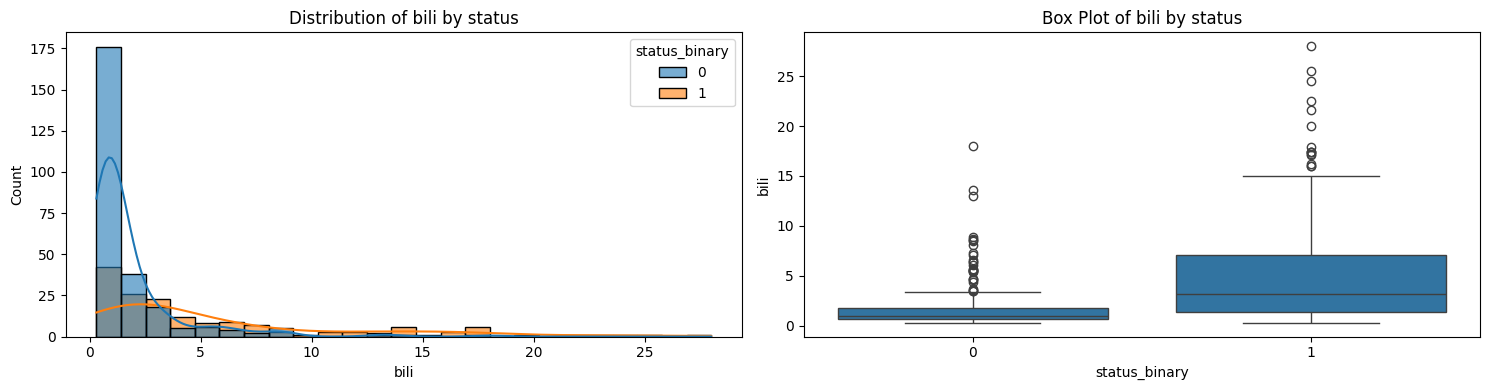

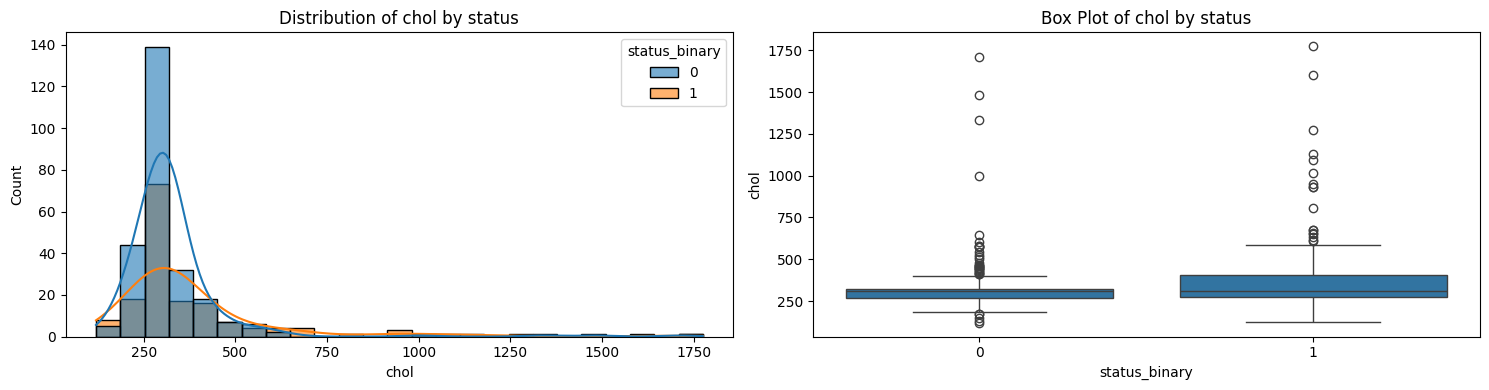

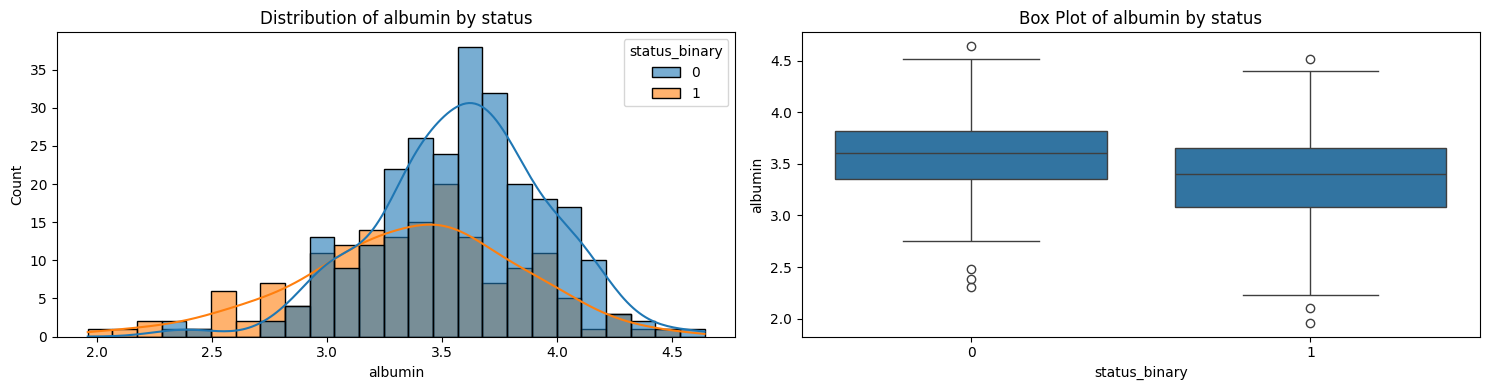

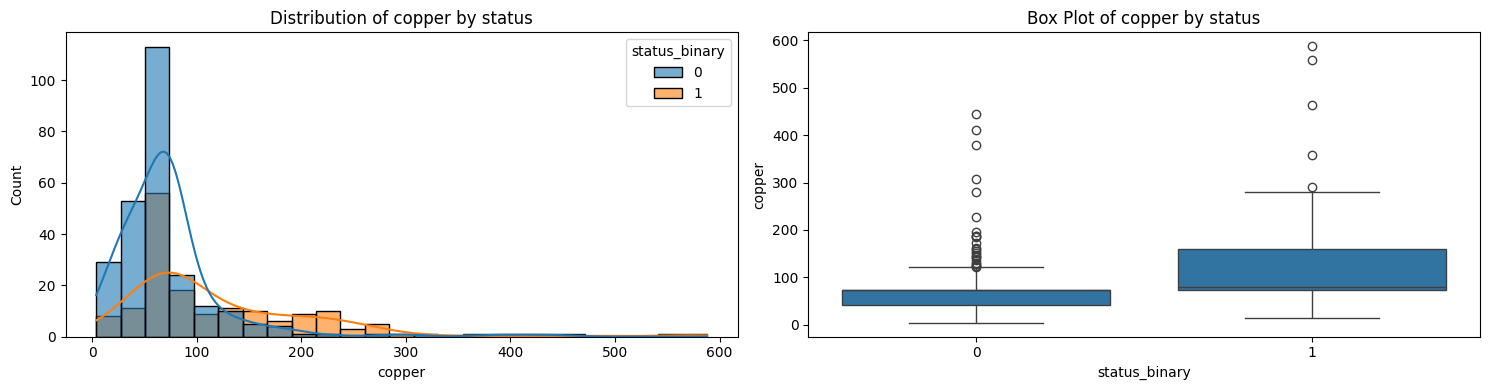

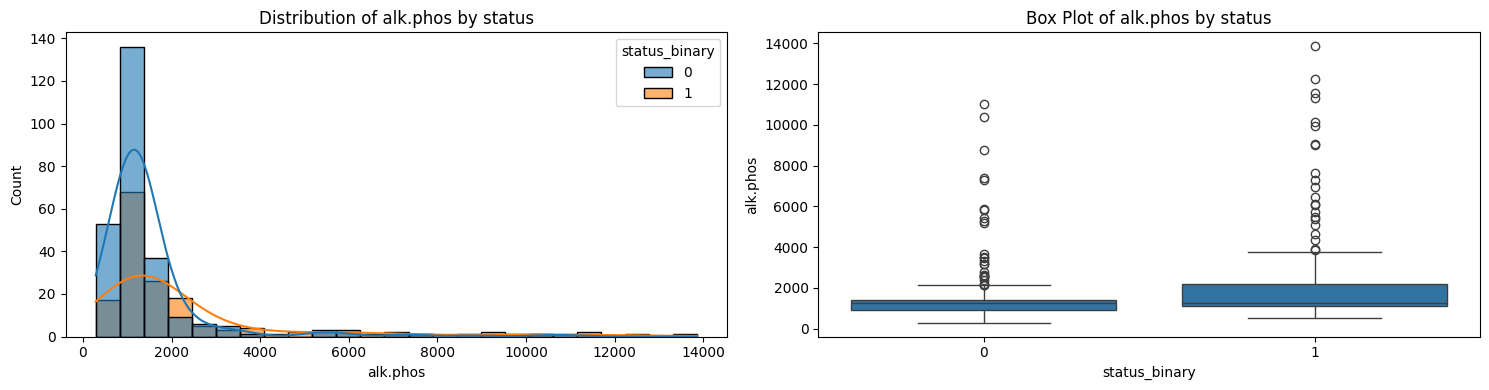

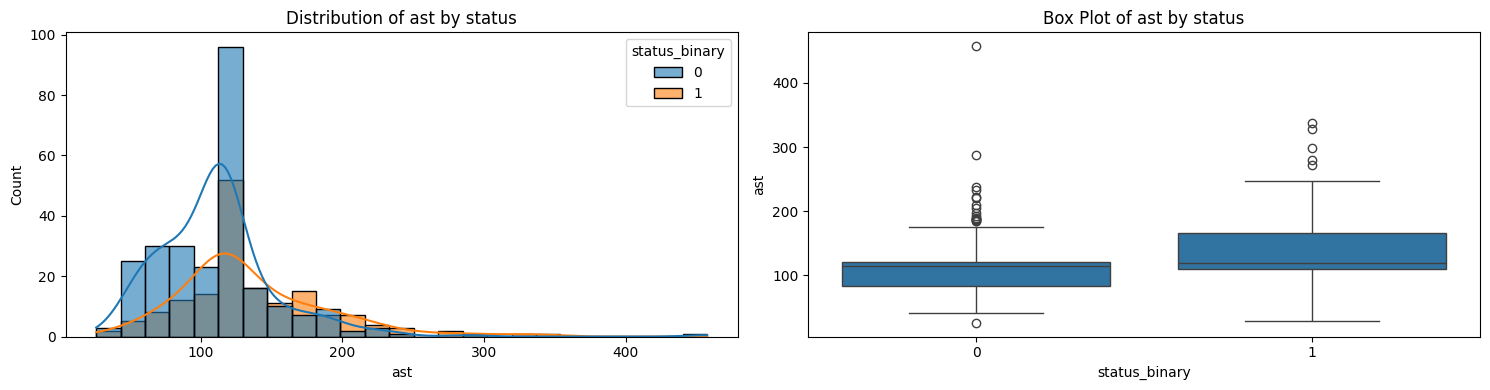

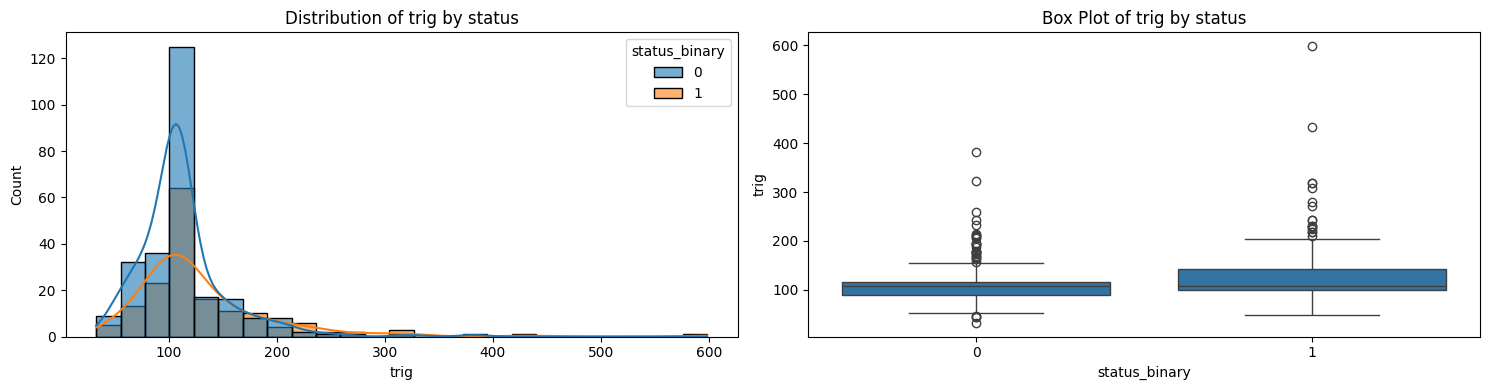

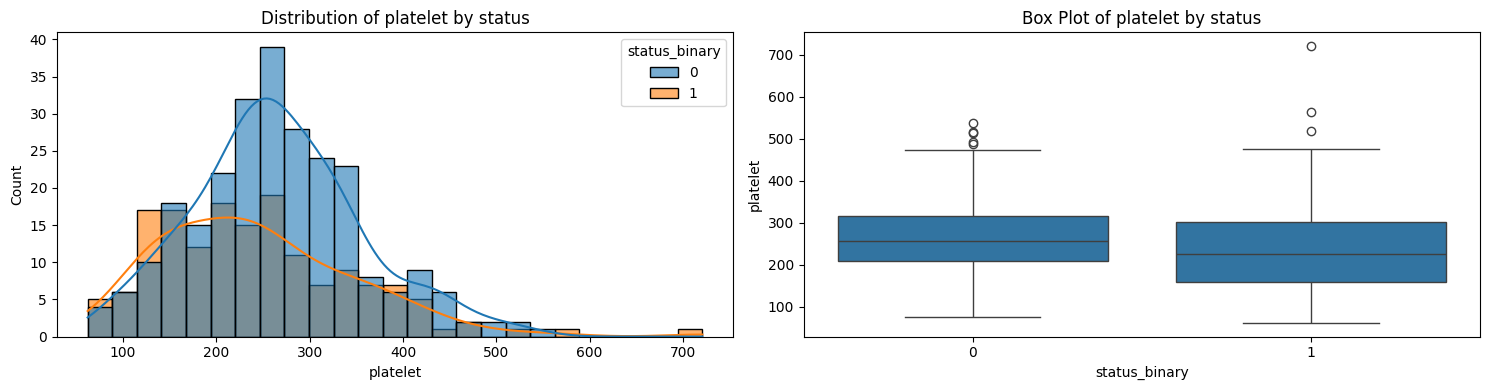

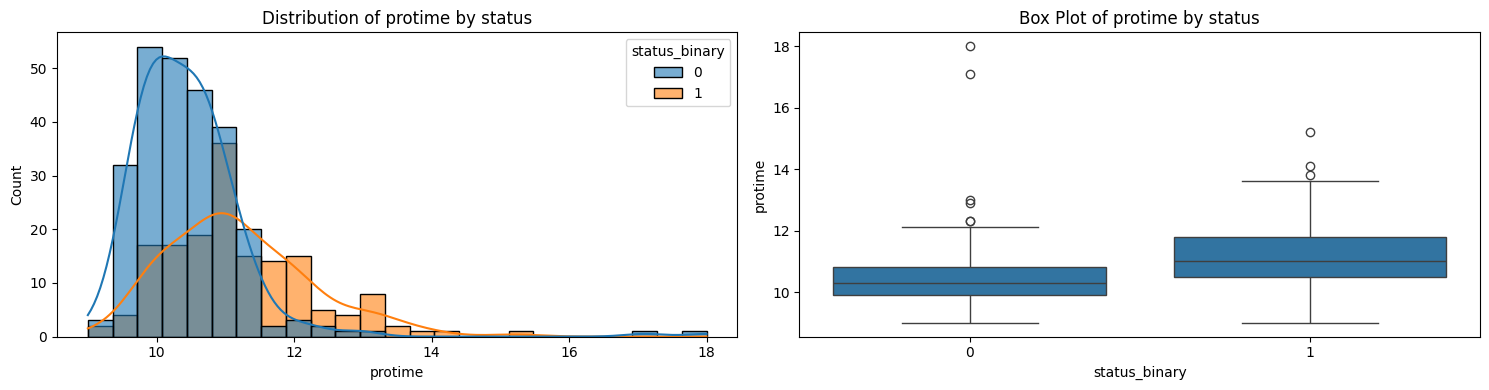

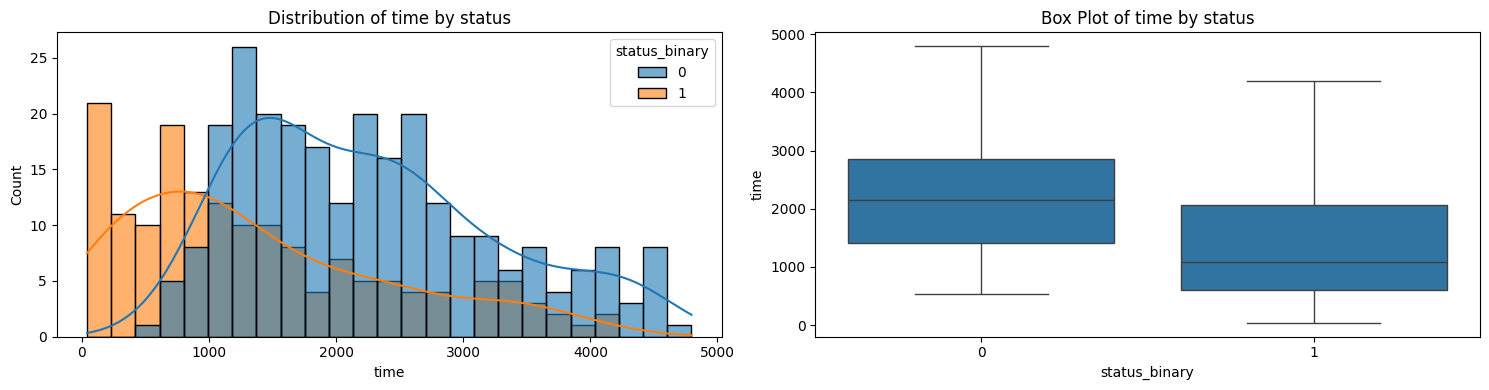

In [58]:
# Distribution of continuous variables by event status
for col in cols_continuous:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    sns.histplot(data=df_pbc, x=col, hue='status_binary', kde=True, bins=25, alpha=0.6, ax=axes[0])
    axes[0].set_title(f"Distribution of {col} by status")
      
    sns.boxplot(data=df_pbc, x='status_binary', y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col} by status")
   
    plt.tight_layout()
    plt.show()

#### PBC categorical variable distributions

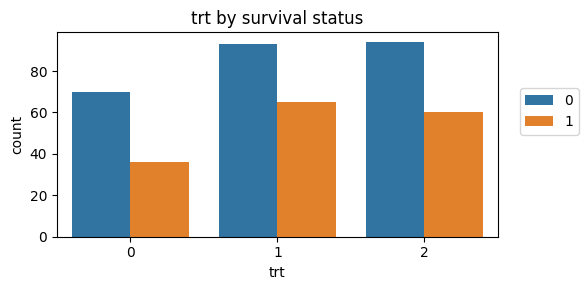

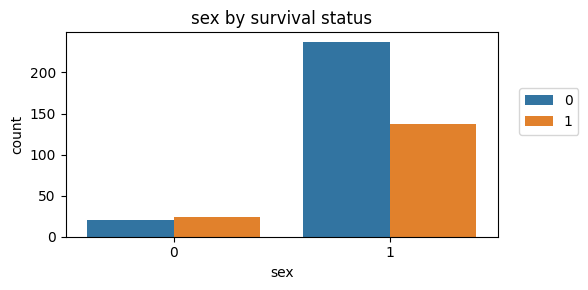

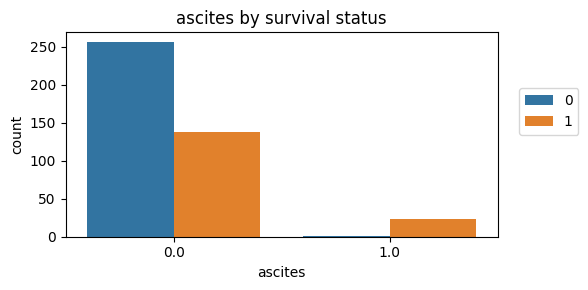

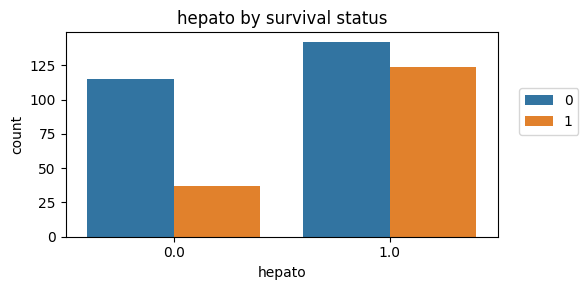

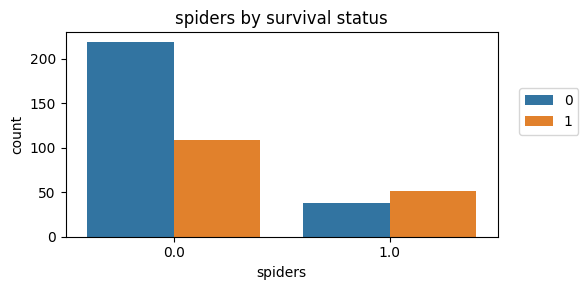

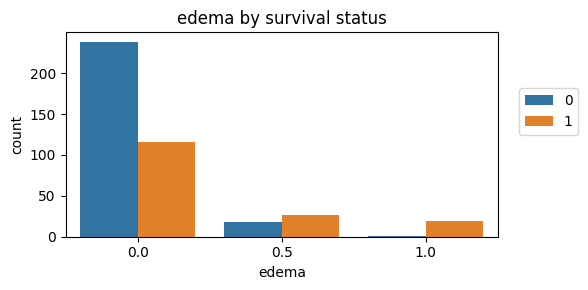

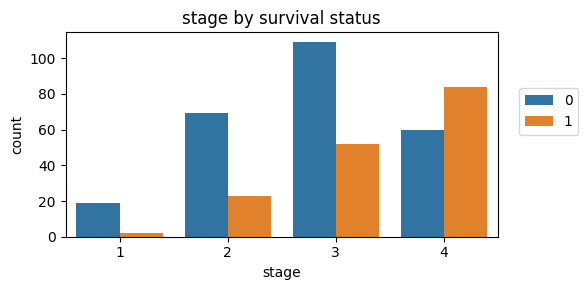

In [59]:
cols_categorical = ['trt', 'sex', 'ascites', 'hepato', 'spiders', 'edema', 'stage']

for col in cols_categorical:
    if col in df_pbc.columns:
        plt.figure(figsize=(6, 3), dpi=100) 
        sns.countplot(data=df_pbc, x=col, hue='status_binary') 
        plt.title(f"{col} by survival status")
        plt.legend(loc=(1.05, 0.5))
        plt.tight_layout()
        plt.show()

#### PBC correlation analysis

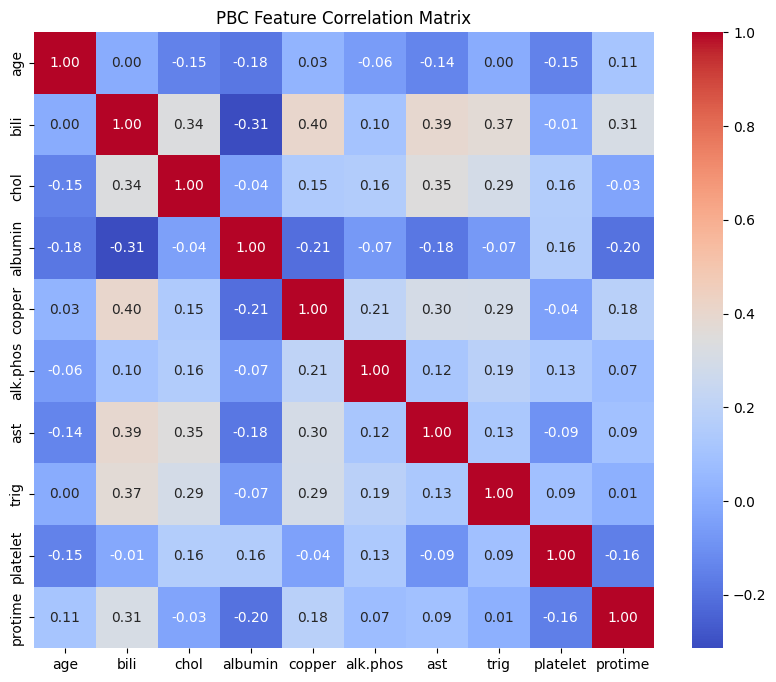

In [60]:
# Correlation matrix for continuous covariates (excluding log transforms and time/status)
corr_cols = ['age', 'bili', 'chol', 'albumin', 'copper', 'alk.phos', 'ast', 'trig', 'platelet', 'protime']

plt.figure(figsize=(10, 8))
corr = df_pbc[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("PBC Feature Correlation Matrix")
plt.show()

#### PBC modelling

In [61]:
T = df_pbc['time']
E = df_pbc['status_binary']

survival_table_from_events(T, E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.0,0,0,0,418,418
41.0,2,2,0,0,418
43.0,1,1,0,0,416
51.0,1,1,0,0,415
71.0,1,1,0,0,414
...,...,...,...,...,...
4500.0,1,0,1,0,5
4509.0,1,0,1,0,4
4523.0,1,0,1,0,3


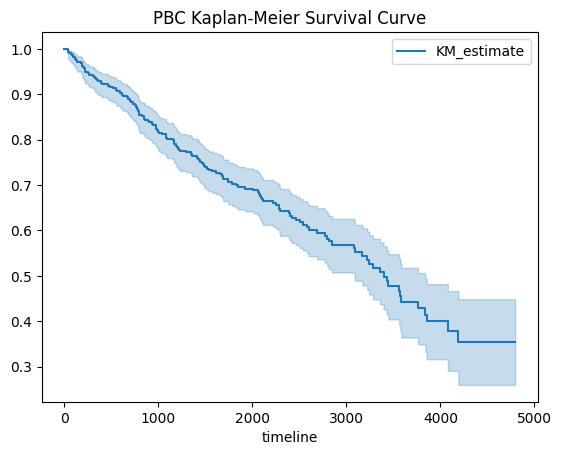

In [62]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)
kmf.plot_survival_function()
plt.title("PBC Kaplan-Meier Survival Curve")
plt.show()

In [63]:
kmf.survival_function_

,KM_estimate
timeline,
0.0,1.000000
41.0,0.995215
43.0,0.992823
51.0,0.990431
71.0,0.988038
...,...
4500.0,0.353396
4509.0,0.353396
4523.0,0.353396


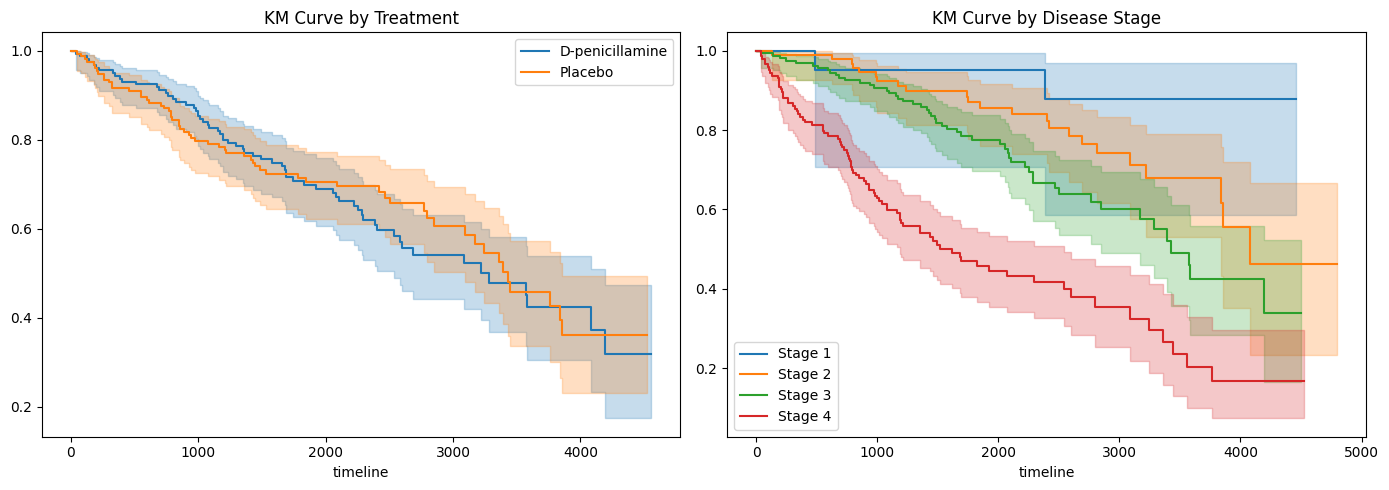

In [64]:
# Kaplan-Meier stratified by treatment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for trt_val, label in [(1, 'D-penicillamine'), (2, 'Placebo')]:
    mask = df_pbc['trt'] == trt_val
    kmf_tmp = KaplanMeierFitter()
    kmf_tmp.fit(df_pbc.loc[mask, 'time'], event_observed=df_pbc.loc[mask, 'status_binary'], label=label)
    kmf_tmp.plot_survival_function(ax=axes[0])
axes[0].set_title("KM Curve by Treatment")

for stage_val in sorted(df_pbc['stage'].dropna().unique()):
    mask = df_pbc['stage'] == stage_val
    kmf_tmp = KaplanMeierFitter()
    kmf_tmp.fit(df_pbc.loc[mask, 'time'], event_observed=df_pbc.loc[mask, 'status_binary'], label=f'Stage {int(stage_val)}')
    kmf_tmp.plot_survival_function(ax=axes[1])
axes[1].set_title("KM Curve by Disease Stage")

plt.tight_layout()
plt.show()

In [65]:
wft = WeibullAFTFitter()
wft.fit(df_pbc[['age', 'log_bili', 'albumin', 'log_copper', 'protime', 'stage', 'edema', 'time', 'status_binary']], 
        duration_col='time', event_col='status_binary')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 418 total observations, 257 right-censored observations>
             duration col = 'time'
                event col = 'status_binary'
   number of observations = 418
number of events observed = 161
           log-likelihood = -1408.79
         time fit was run = 2026-03-31 01:32:16 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                   
lambda_ age        -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
        albumin     0.39      1.47      0.14            0.11            0.66                1.12                1.93
        edema      -0.56      0.57      0.18           -0.91           -0.21                0.40                0.81
        log_bili   -0.64      0.52      0.08           -0.79           -0.50                0.45                0.61
        log_copper -0.24      0.79      0.08           -0.40           -0.07                0.67                0.93
        protime    -0.12      0.88      0.05           -0.21           -0.03                0.81                0.97
        stage      -0.23      0.79      0.08           -0.38           -0.08                0.68                0.92
        Intercept  11.90  1.48e+05      0.94           10.06           13.75            23275.05            9.39e+05
rho_    Intercept   0.40      1.50      0.06            0.28            0.53                1.32                1.69

                    cmp to     z      p  -log2(p)
param   covariate                                
lambda_ age           0.00 -4.03 <0.005     14.11
        albumin       0.00  2.78   0.01      7.51
        edema         0.00 -3.16 <0.005      9.29
        log_bili      0.00 -8.44 <0.005     54.83
        log_copper    0.00 -2.82 <0.005      7.70
        protime       0.00 -2.65   0.01      6.94
        stage         0.00 -3.03 <0.005      8.68
        Intercept     0.00 12.62 <0.005    118.88
rho_    Intercept     0.00  6.41 <0.005     32.64
---
Concordance = 0.85
AIC = 2835.57
log-likelihood ratio test = 244.46 on 7 df
-log2(p) of ll-ratio test = 160.71

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

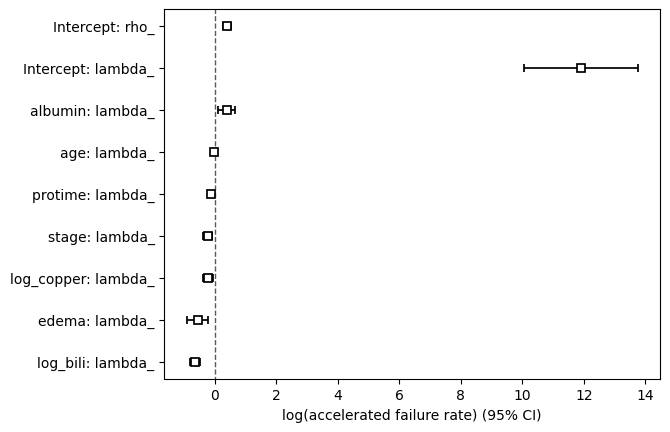

In [66]:
wft.plot()

In [67]:
# Features for Cox PH (using log-transformed skewed variables, excluding raw versions)
features_pbc = ['age', 'log_bili', 'albumin', 'log_copper', 'log_alkphos', 'log_ast', 
                'protime', 'edema', 'time', 'status_binary']

In [68]:
# saving the preprocessed dataframe
df_pbc[features_pbc].to_csv(r'./data/preprocess-data/preprocess_pbc.csv')

In [69]:
cph = CoxPHFitter()
cph.fit(df_pbc[features_pbc], duration_col='time', event_col='status_binary', 
        strata=['edema'])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
             duration col = 'time'
                event col = 'status_binary'
                   strata = edema
      baseline estimation = breslow
   number of observations = 418
number of events observed = 161
   partial log-likelihood = -647.02
         time fit was run = 2026-03-31 01:32:17 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
age          0.04      1.04      0.01            0.03            0.06                1.03                1.06
log_bili     0.95      2.58      0.13            0.70            1.20                2.01                3.31
albumin     -0.75      0.47      0.21           -1.16           -0.34                0.31                0.72
log_copper   0.32      1.37      0.14            0.04            0.59                1.04                1.80
log_alkphos -0.04      0.96      0.12           -0.29            0.20                0.75                1.22
log_ast      0.34      1.41      0.25           -0.15            0.83                0.86                2.29
protime      0.19      1.21      0.06            0.07            0.31                1.07                1.37

             cmp to     z      p  -log2(p)
covariate                                 
age            0.00  5.03 <0.005     20.94
log_bili       0.00  7.46 <0.005     43.42
albumin        0.00 -3.56 <0.005     11.40
log_copper     0.00  2.26   0.02      5.39
log_alkphos    0.00 -0.36   0.72      0.48
log_ast        0.00  1.36   0.17      2.52
protime        0.00  3.03 <0.005      8.66
---
Concordance = 0.82
Partial AIC = 1308.03
log-likelihood ratio test = 164.87 on 7 df
-log2(p) of ll-ratio test = 104.70


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 418 total observations, 257 right-censored observations>
         test_name = proportional_hazard_test

---
                  test_statistic      p  -log2(p)
age         km              1.17   0.28      1.84
            rank            5.35   0.02      5.60
albumin     km              0.78   0.38      1.41
            rank            1.29   0.26      1.97
log_alkphos km              2.61   0.11      3.24
            rank            1.09   0.30      1.76
log_ast     km              0.72   0.40      1.33
            rank            0.03   0.87      0.20
log_bili    km              1.82   0.18      2.50
            rank            1.72   0.19      2.40
log_copper  km              1.35   0.24      2.03
            rank            0.89   0.35      1.53
protime     km              8.16 <0.005      7.86
            rank            1.34   0.25      2.02



1. Variable 'age' failed the non-proportional test: p-value is 0.0207.

   Advice 1: the functional form of the variable 'age' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age' using pd.cut, and then specify it in `strata=['age',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


2. Variable 'protime' failed the non-proportional 

[[<Axes: xlabel='rank-transformed time\n(p=0.0207)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2787)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1893)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1769)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2555)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3764)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3466)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2447)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2960)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1061)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8681)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3967)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2469)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0043)'>]]

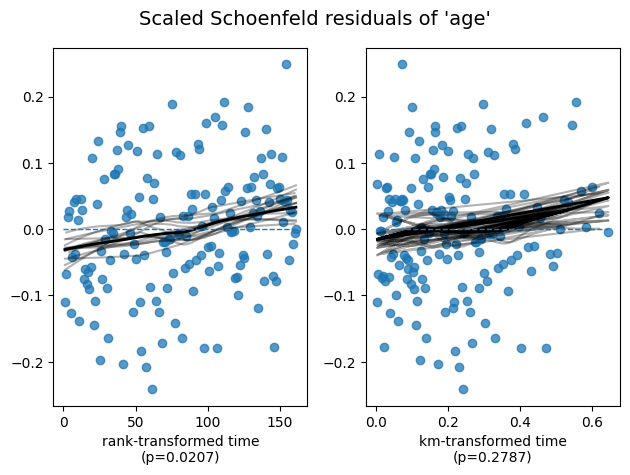

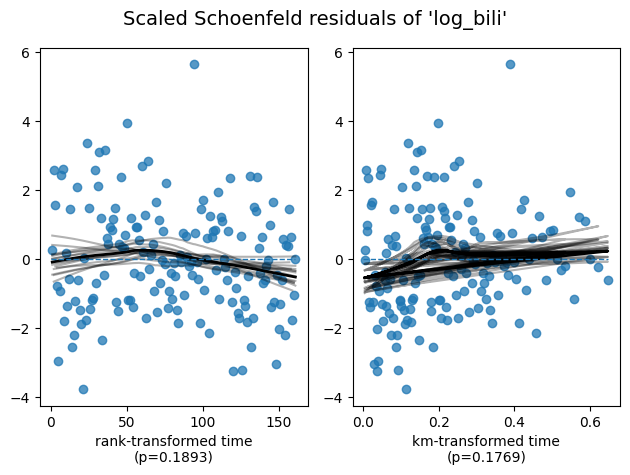

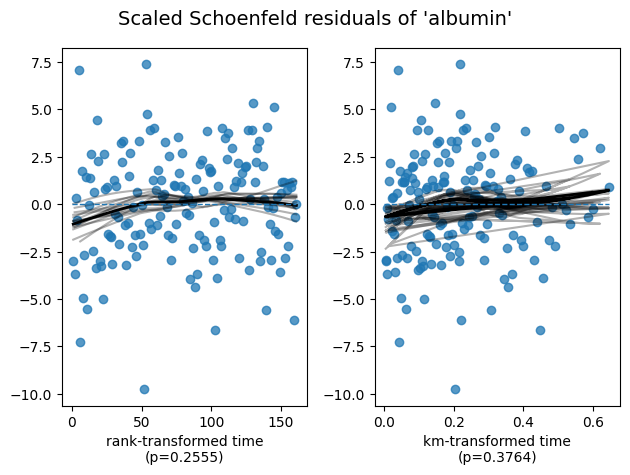

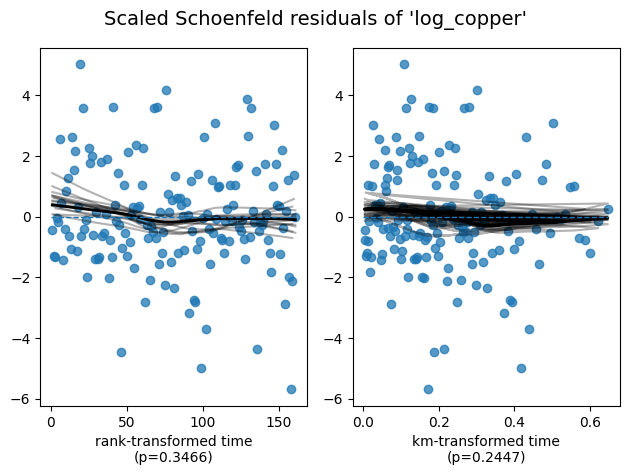

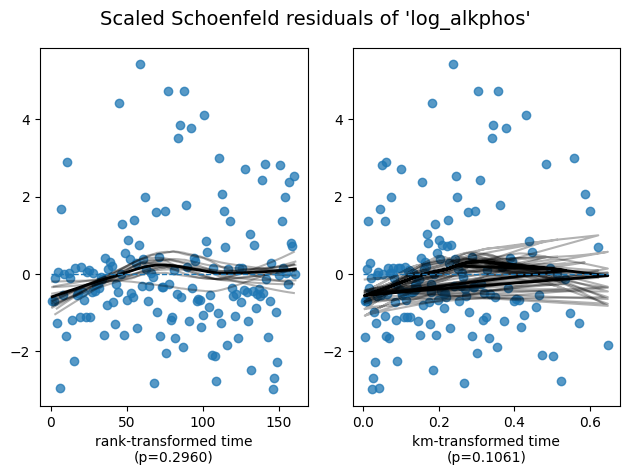

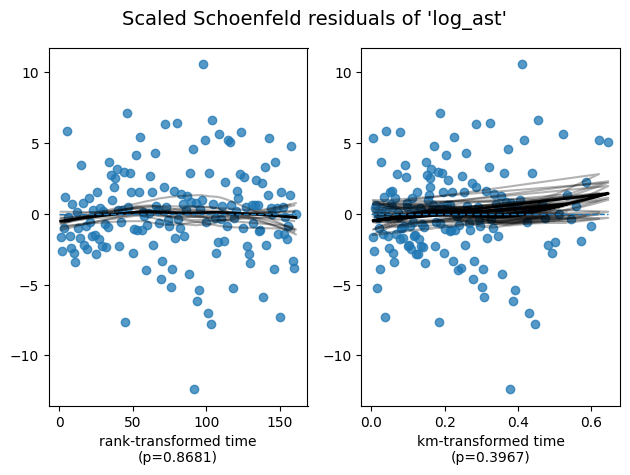

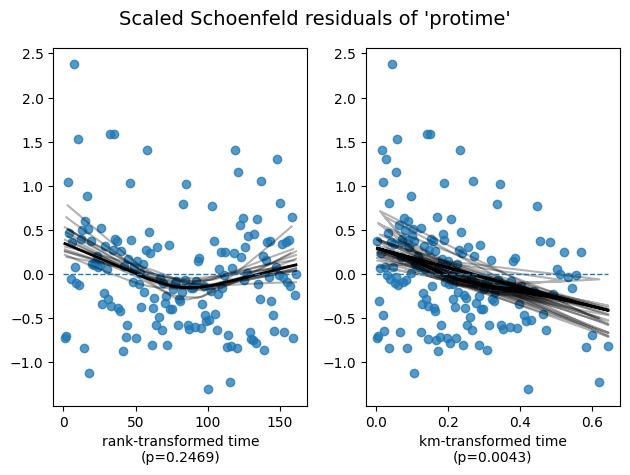

In [70]:
cph.check_assumptions(df_pbc[features_pbc], show_plots=True, p_value_threshold=0.05)

In [71]:
scores = k_fold_cross_validation(
    cph, df_pbc[features_pbc], duration_col='time', event_col='status_binary', k=5,
    scoring_method='concordance_index'
)

print("Average C-index:", np.mean(scores))

c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


Average C-index: 0.8282465429865823


c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


In [72]:
pred = cph.predict_partial_hazard(df_pbc)
c_index_pbc = concordance_index(df_pbc["time"], -pred, df_pbc["status_binary"])
print("CoxPH C-index:", c_index_pbc)

CoxPH C-index: 0.836049812288252


In [73]:
ibs_pbc = compute_ibs(
    cph=cph,
    df=df_pbc,
    duration_col="time",
    event_col="status_binary"
)

print("CoxPH IBS:", ibs_pbc)

CoxPH IBS: 0.25843059231430504


In [74]:
# AIC score
print("AIC:", cph.AIC_partial_)

AIC: 992.4872917404724


In [75]:
log_likelihood = cph.log_likelihood_
k = len(cph.params_)
n = cph._n_examples

bic = -2 * log_likelihood + k * np.log(n)

print("BIC:", bic)

BIC: 1019.1862054632479


### Simulated Data

In [76]:
df_sd.shape

(200, 5)

In [77]:
df_sd.head(10)

,Age,Treatment,Sex,Time,Event
0,54.967142,1,1,0.075964,1
1,48.617357,1,0,0.196966,1
2,56.476885,1,0,0.226271,1
3,65.230299,1,1,0.074202,1
4,47.658466,0,0,0.190551,1
5,47.658630,0,1,0.253558,1
6,65.792128,1,0,0.095786,1
7,57.674347,1,1,0.631463,0
8,45.305256,1,0,0.117190,1
9,55.425600,1,1,0.514171,1


In [78]:
df_sd.isna().sum()

Age          0
Treatment    0
Sex          0
Time         0
Event        0
dtype: int64

In [79]:
df_sd['Log_age'] = np.log1p(df_sd['Age'])

In [80]:
df_sd.describe()

,Age,Treatment,Sex,Time,Event,Log_age
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,49.592290,0.520000,0.500000,0.624313,0.705000,3.906338
std,9.310039,0.500854,0.501255,0.732027,0.457187,0.189906
min,23.802549,0.000000,0.000000,0.004059,0.000000,3.210946
25%,42.948723,0.000000,0.000000,0.151343,0.000000,3.783023
50%,49.958081,1.000000,0.500000,0.398990,1.000000,3.931002
75%,55.008525,1.000000,1.000000,0.832125,1.000000,4.025503
max,77.201692,1.000000,1.000000,4.463726,1.000000,4.359291


In [81]:
print(df_sd["Event"].value_counts())

print("\nIn Percentage:")
print(df_sd['Event'].value_counts(normalize = True))

Event
1    141
0     59
Name: count, dtype: int64

In Percentage:
Event
1    0.705
0    0.295
Name: proportion, dtype: float64


In [82]:
event_rate = df_sd["Event"].mean()
censor_rate = 1 - event_rate

print(f"Event rate: {event_rate:.2f}")
print(f"Censoring rate: {censor_rate:.2f}")


Event rate: 0.70
Censoring rate: 0.30


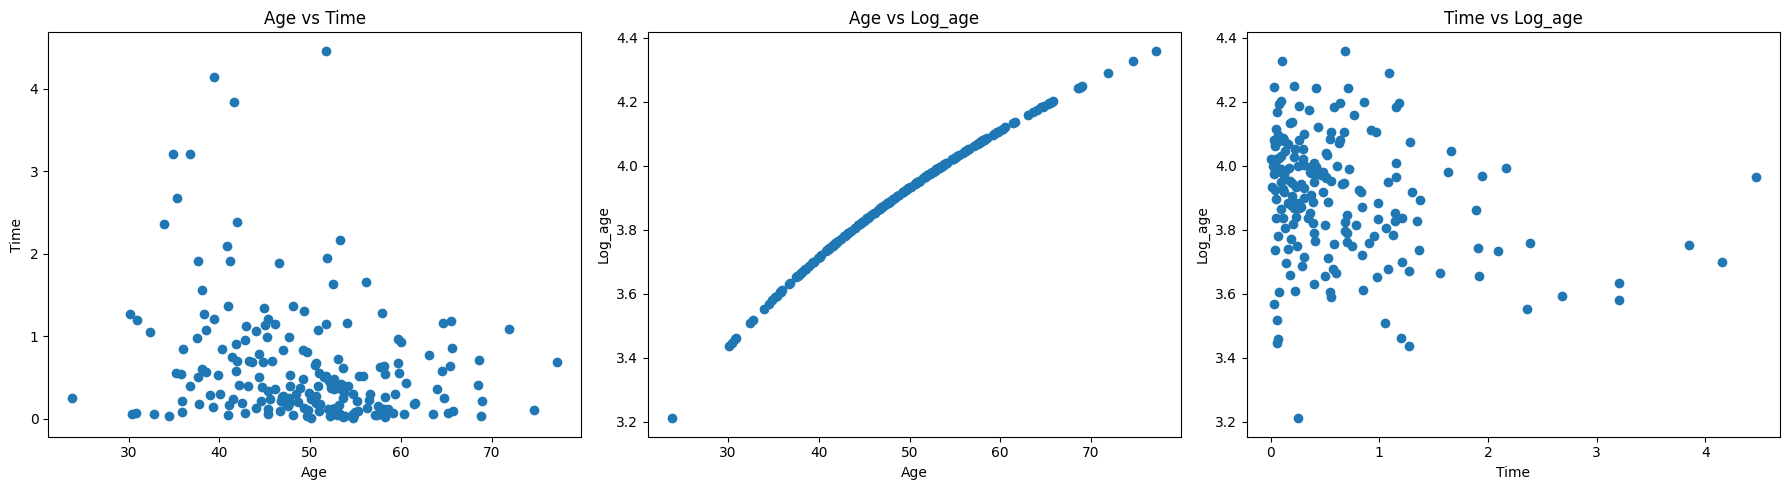

In [83]:
cols = ['Age', 'Time', 'Log_age']

pairs = list(itertools.combinations(cols, 2))
n = len(pairs)

# Create one figure with subplots
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))

# Make axes iterable when n == 1
if n == 1:
    axes = [axes]

for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_sd[x], df_sd[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

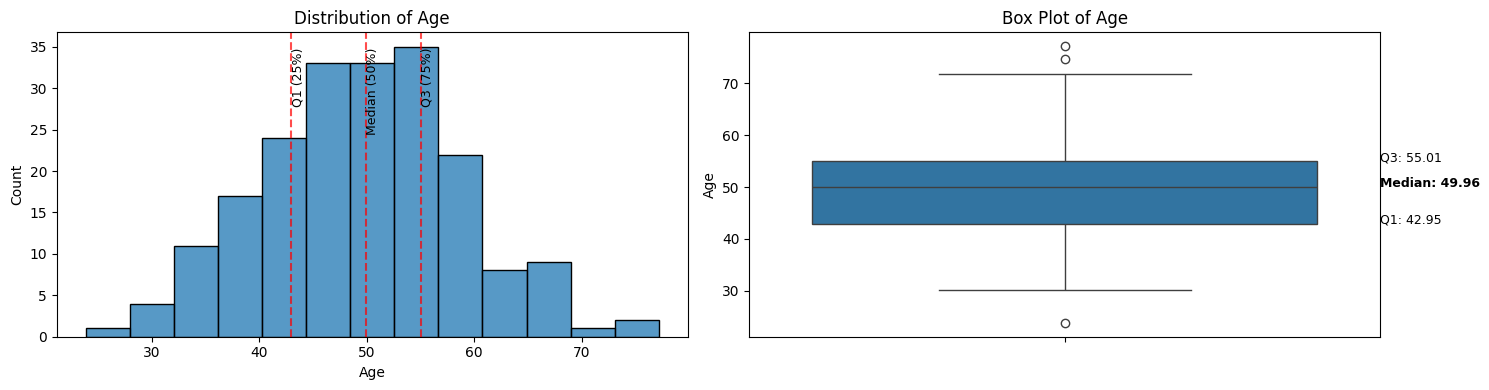

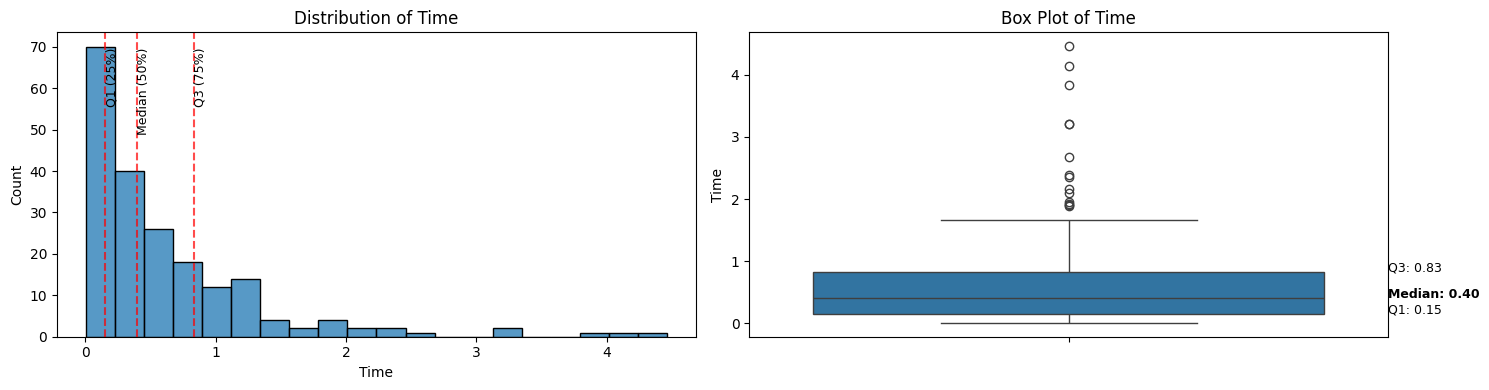

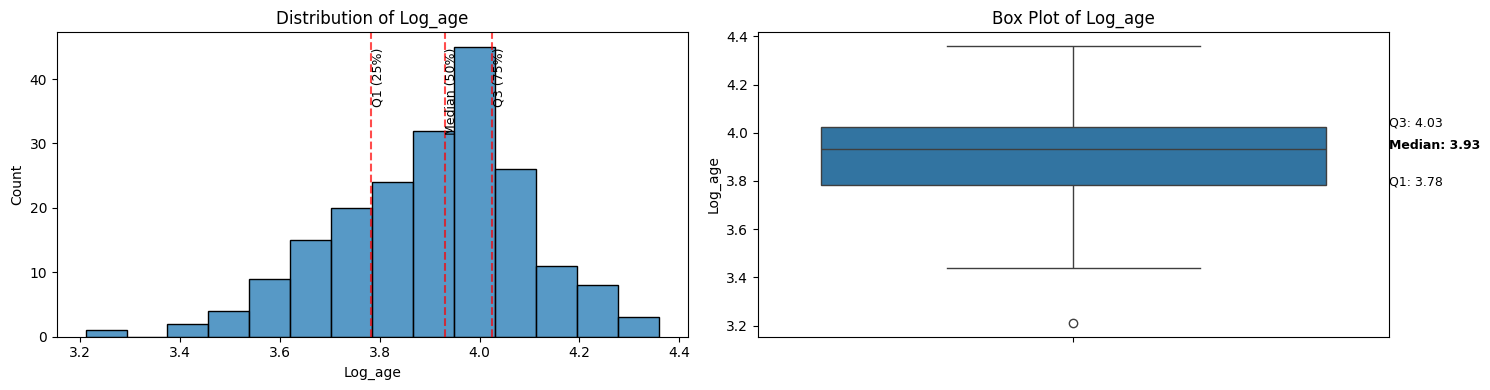

In [84]:
for col in cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
   
    # Plot 1: Overlapping histograms with quantiles
    sns.histplot(data=df_sd, x=col, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    
    # Add quantile lines (25th, 50th, 75th percentiles)
    quantiles = df_sd[col].quantile([0.25, 0.5, 0.75])
    for q_val, label in zip(quantiles, ['Q1 (25%)', 'Median (50%)', 'Q3 (75%)']):
        axes[0].axvline(q_val, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        axes[0].text(q_val, axes[0].get_ylim()[1]*0.95, label, 
                    rotation=90, verticalalignment='top', fontsize=9)
    
    # Plot 2: Box plot (fixed - removed duplicate x and y)
    sns.boxplot(data=df_sd, y=col, ax=axes[1])
    axes[1].set_title(f"Box Plot of {col}")
    
    # Add quantile values as text on boxplot
    q1, median, q3 = df_sd[col].quantile([0.25, 0.5, 0.75])
    axes[1].text(0.5, q1, f'Q1: {q1:.2f}', ha='left', fontsize=9)
    axes[1].text(0.5, median, f'Median: {median:.2f}', ha='left', fontsize=9, weight='bold')
    axes[1].text(0.5, q3, f'Q3: {q3:.2f}', ha='left', fontsize=9)
   
    plt.tight_layout()
    plt.show()

In [85]:
df_sd[cols].corr().abs()

,Age,Time,Log_age
Age,1.000000,0.250167,0.991009
Time,0.250167,1.000000,0.254205
Log_age,0.991009,0.254205,1.000000


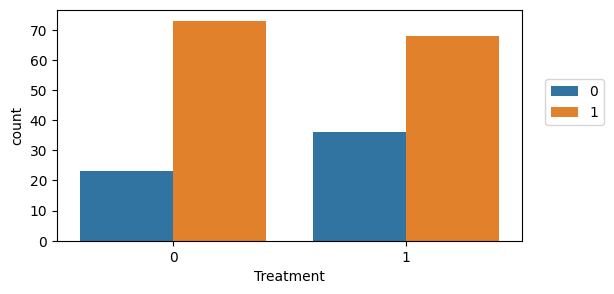

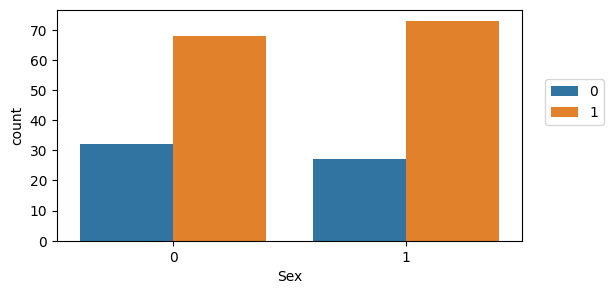

In [86]:
cols_qualitative = ['Treatment', 'Sex']

for col in cols_qualitative:
    plt.figure(figsize=(6,3), dpi=100)
    sns.countplot(data=df_sd, x=col, hue='Event')
    plt.legend(loc=(1.05, 0.5))
    plt.show()


In [87]:
df_sd = df_sd.drop('Log_age', axis=1)

#### Modelling

In [88]:
T = df_sd['Time']
E = df_sd['Event']

survival_table_from_events(T,E)

,removed,observed,censored,entrance,at_risk
event_at,,,,,
0.000000,0,0,0,200,200
0.004059,1,1,0,0,200
0.010749,1,1,0,0,199
0.022113,1,0,1,0,198
0.026174,1,0,1,0,197
...,...,...,...,...,...
3.205239,1,1,0,0,5
3.206745,1,0,1,0,4
3.845280,1,1,0,0,3


<Axes: xlabel='timeline'>

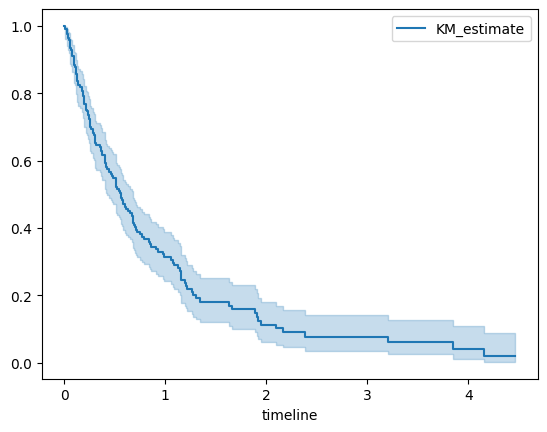

In [89]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)
kmf.plot_survival_function()

In [90]:
kmf.survival_function_

,KM_estimate
timeline,
0.000000,1.000000
0.004059,0.995000
0.010749,0.990000
0.022113,0.990000
0.026174,0.990000
...,...
3.205239,0.062044
3.206745,0.062044
3.845280,0.041362


In [91]:
wft = WeibullAFTFitter()
wft.fit(df_sd, duration_col='Time', event_col='Event')
wft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
   number of observations = 200
number of events observed = 141
           log-likelihood = -105.22
         time fit was run = 2026-03-31 01:32:23 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ Age       -0.04      0.96      0.01           -0.06           -0.03                0.94                0.97
        Sex       -0.25      0.78      0.17           -0.58            0.07                0.56                1.07
        Treatment  0.50      1.65      0.16            0.18            0.81                1.20                2.25
        Intercept  1.92      6.80      0.46            1.02            2.81                2.77               16.69
rho_    Intercept  0.05      1.05      0.06           -0.08            0.18                0.93                1.19

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ Age          0.00 -5.46 <0.005     24.35
        Sex          0.00 -1.53   0.13      2.98
        Treatment    0.00  3.10 <0.005      9.02
        Intercept    0.00  4.18 <0.005     15.09
rho_    Intercept    0.00  0.76   0.45      1.17
---
Concordance = 0.64
AIC = 220.44
log-likelihood ratio test = 36.39 on 3 df
-log2(p) of ll-ratio test = 23.95

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

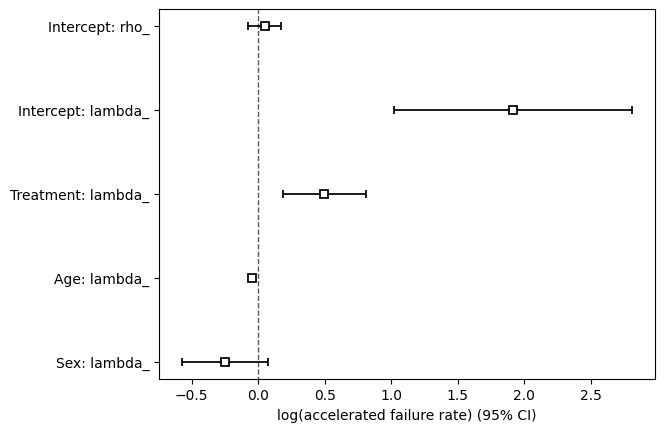

In [92]:
wft.plot()

In [93]:
# saving the dataframe
df_sd.to_csv(r'./data/preprocess-data/preprocess_simulated_data.csv')

In [94]:
cph = CoxPHFitter()
cph.fit(df_sd, duration_col='Time', event_col='Event', strata=['Treatment' ,'Sex', ])
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                   strata = ['Treatment', 'Sex']
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -405.34
         time fit was run = 2026-03-31 01:32:24 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Age        0.04      1.05      0.01            0.03            0.06                1.03                1.06

           cmp to    z      p  -log2(p)
covariate                              
Age          0.00 4.98 <0.005     20.56
---
Concordance = 0.65
Partial AIC = 812.67
log-likelihood ratio test = 23.95 on 1 df
-log2(p) of ll-ratio test = 19.95


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4300)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9466)'>]]

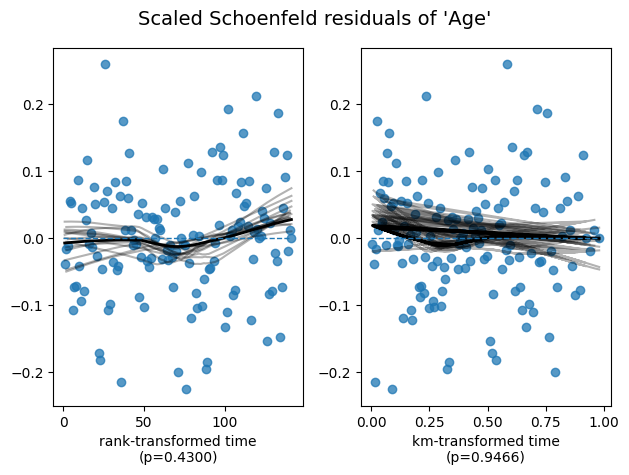

In [95]:
cph.check_assumptions(df_sd, show_plots=True, p_value_threshold=0.05)

In [96]:
scores = k_fold_cross_validation(
    cph, df_sd, duration_col='Time', event_col='Event', k=5,
    scoring_method='concordance_index'
)

print("Average C-index:", np.mean(scores))

c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")
c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index i

Average C-index: 0.6462387629826615


c:\Users\RASHMIKA\AppData\Local\Programs\Python\Python312\Lib\site-packages\lifelines\utils\__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


In [97]:
pred = cph.predict_partial_hazard(df_sd)
c_index_hm = concordance_index(df_sd["Time"], -pred, df_sd["Event"])
print("CoxPH C-index:", c_index_hm)

CoxPH C-index: 0.6412972972972973


In [98]:
ibs_sd = compute_ibs(
    cph=cph,
    df=df_sd,
    duration_col="Time",
    event_col="Event"
)

print("CoxPH IBS:", ibs_sd)

CoxPH IBS: 0.1257472922858238


In [99]:
# AIC score
print("AIC:", cph.AIC_partial_)

AIC: 588.7890906570949


In [100]:
log_likelihood = cph.log_likelihood_
k = len(cph.params_)
n = cph._n_examples

bic = -2 * log_likelihood + k * np.log(n)

print("BIC:", bic)

BIC: 591.8642644723287
